In [ ]:
# basic notebook for plotting logos from annotated seqlets for highlighting specific examples #

In [1]:
# import packages
import pandas as pd
import numpy as np
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import torch
import os
# tangermeme packages
from tangermeme.seqlet import recursive_seqlets
from tangermeme.plot import plot_logo
from tangermeme.annotate import annotate_seqlets
from tangermeme.io import read_meme
import logomaker

In [2]:
# define a function for reading in data and concatenating #
def read_in_sat_mut (path2satmut, chunksize):
    # define a list for concatenating #
    chunks2cat = []
    # iterate through chunked tsv #
    for chunk in tqdm(pd.read_csv(path2satmut, sep = '\t', chunksize=chunksize)):
        chunks2cat.append(chunk)
    # concatenate chunks #
    cat_df = pd.concat(chunks2cat)
    return cat_df

In [3]:
# dictionary structure for passing to plotting function to:
# filter the summary dataframe for:
# lead variant highlight
# other emVar highlights (with allele frequencies)
# dict(
# cell_type : 'k562',
# enhancer_id : 'ENH...,
# phenotype : 'blah')

In [4]:
def plot_specific_enhancers(enhancer_id,
                            enhStart,
                            chrom,
                            collapsedSeqletBED,
                            summaryDF, # to automatically highlight lead/rare variants
                            varParams, # dictionary to highlight variants
                            varType,
                            cell):
    # define highlight color
    if cell == 'K562':
        highlight = '#00A79D'
    elif cell == 'HepG2':
        highlight = '#FBB040'
    elif cell == 'SKNSH':
        highlight = '#ED1C24'
    # filter the summary df for the enhancer/cell/trait/phenotype of interest
    # check if eQTL or GWAS
    if varType == 'GWAS':
        variantData = summaryDF[
            (summaryDF['cell_type'] == varParams.get('cell_type')) & # filter for the cell type in which it was identified
            (summaryDF['enhancer_ids'] == varParams.get('enhancer_id')) & # get the enhancer
            (summaryDF['traitFromSource'] == varParams.get('phenotype')) & # get the phenotype
            (summaryDF['af'].isna() == False) # drop variants without an allele frequency
        ]
        # get lead variant
        leadVar = int(variantData['leadVariant'].tolist()[0].split('_')[1])
        # get the other variants
        rareVars = variantData[variantData['is_leadVariant'] == 0]['pos'].tolist()
        # get skew direction of rareVars
        skewDir = []
        for var in rareVars:
            varSkew = variantData[variantData['pos'] == var]['skew_pred'].tolist()[0]
            if varSkew < 0:
                skewDir.append(1)
            else:
                skewDir.append(0)
    else:
        variantData = summaryDF[
            (summaryDF['cell_type'] == varParams.get('cell_type')) & # filter for the cell type in which it was identified
            (summaryDF['enhancer_ids'] == varParams.get('enhancer_id')) & # get the enhancer
            (summaryDF['phenotype_id'] == varParams.get('phenotype')) & # get the phenotype
            (summaryDF['af'].isna() == False) # drop variants without an allele frequency
        ]
        # get lead variant
        leadVar = int(variantData['leadVar'].tolist()[0].split('_')[1])
        # get the other variants
        rareVars = variantData[variantData['is_leadVariant'] == 0]['pos'].tolist()
        # get skew direction of rareVars
        skewDir = []
        for var in rareVars:
            varSkew = variantData[variantData['pos'] == var]['skew_pred'].tolist()[0]
            if varSkew > 0:
                skewDir.append(1)
            else:
                skewDir.append(0)

    # load the tensors
    plotLogo_tensors = torch.load(f'/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/processed_data/seqlets_calling/seqlets_by_chrom/{chrom}_plotLogo_tensors.pt')
    
    # get the seqlets for the BED file
    enhBED = collapsedSeqletBED[collapsedSeqletBED['enhancer_id'] == enhancer_id]
    
    # pull the tensors for the enhancer for that cell type
    tensors2plot = plotLogo_tensors[cell][enhancer_id]
    
    # get the max/min attributions for highlighting seqlets
    minAttrib = tensors2plot.min().min() * 1.05
    maxAttrib = tensors2plot.max().max() * 1.05
    
    # build the DF for plotting with logomaker
    dfFromTensor = pd.DataFrame(tensors2plot.numpy()).T.copy()
    renamedDF = dfFromTensor.rename(columns={0: 'A', 1: 'C', 2: 'G', 3: 'T'})
    
    # remove zero-padded positions at ends
    renamedDF = renamedDF.loc[renamedDF.sum(axis=1) != 0]
    
    # adjust enhStart to account for left padding, then reset index to start at 0
    enhStart = enhStart + renamedDF.index[0]
    renamedDF = renamedDF.reset_index(drop=True)
    seq_length = len(renamedDF)

    # set plot parameters
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    matplotlib.rcParams['figure.dpi'] = 300
    
    # generate base plot with extra space for annotations
    fig, ax = plt.subplots(figsize=[20, 2.5])
    logoCheck = logomaker.Logo(renamedDF, ax=ax)
    
    # set y-limits based on data only
    logoCheck.ax.set_ylim(minAttrib, maxAttrib)
    
    # track annotation positions to avoid collisions
    top_annotations = []
    bottom_annotations = []
    min_spacing = 3
    
    def get_annotation_level(x_center, text_half_width, existing_annotations):
        """Find the lowest level where this annotation won't overlap with others."""
        level = 0
        while True:
            conflict = False
            for other_center, other_half_width, other_level in existing_annotations:
                if other_level == level:
                    distance = abs(x_center - other_center)
                    min_dist = text_half_width + other_half_width + min_spacing
                    if distance < min_dist:
                        conflict = True
                        break
            if not conflict:
                return level
            level += 1
    
    # highlight seqlets and collect annotation info
    for idx, row in enhBED.iterrows():
        start, stop, actClass, tf = row[['start', 'end', 'activity_class', 'tf_family']].tolist()
        start = int(start - enhStart)
        stop = int(stop - enhStart - 1)
        x_center = (stop + start) / 2
        x_center_norm = x_center / seq_length  # normalize to 0-1 for axes coords
        tf_label = tf.split('_')[0]
        text_half_width = len(tf_label) * 2.5
        
        if actClass == 'Activator':
            logoCheck.highlight_position_range(pmin=start, pmax=stop, alpha=0.5, color='gainsboro', edgecolor='k', floor=0)
            
            level = get_annotation_level(x_center, text_half_width, top_annotations)
            top_annotations.append((x_center, text_half_width, level))
            
            # draw bracket line in data coords
            #bracket_y = maxAttrib * 1.05 + level  # above the y-limit
            #ax.plot([start, stop], [bracket_y, bracket_y], color='k', linewidth=1, solid_capstyle='butt', clip_on=False)
            
            # annotate in axes coords (outside plot area)
            y_offset = 1.05 + level * 0.05
            ax.annotate(tf_label,
                        xy=(x_center_norm, 1.0),  # anchor at top of axes
                        xycoords='axes fraction',
                        xytext=(x_center_norm, y_offset),
                        textcoords='axes fraction',
                        fontsize=8, fontstyle='italic',
                        ha='center', va='bottom',
                        annotation_clip=False)
        else:
            logoCheck.highlight_position_range(pmin=start, pmax=stop, alpha=0.5, color='gainsboro', edgecolor='k', ceiling=0)
            
            level = get_annotation_level(x_center, text_half_width, bottom_annotations)
            bottom_annotations.append((x_center, text_half_width, level))
            
            # draw bracket line in data coords
            #bracket_y = minAttrib * 1.05 + level  # below the y-limit (more negative)
            #ax.plot([start, stop], [bracket_y, bracket_y], color='k', linewidth=1, solid_capstyle='butt', clip_on=False)
            
            # annotate in axes coords (outside plot area)
            y_offset = -0.01 - level * 0.12
            ax.annotate(tf_label,
                        xy=(x_center_norm, 0.0),  # anchor at bottom of axes
                        xycoords='axes fraction',
                        xytext=(x_center_norm, y_offset),
                        textcoords='axes fraction',
                        fontsize=8, fontstyle='italic',
                        ha='center', va='top',
                        annotation_clip=False)
    
    # highlight lead Variant
    LeadVar = int(leadVar - enhStart - 1)
    logoCheck.highlight_position(p=LeadVar, color='red', alpha=0.5, floor=0)
    
    # highlight larger effect variants
    for var, effectDir in zip(rareVars, skewDir):
        # check skew at that position
        if effectDir == 1: 
            var2plot = int(var - enhStart - 1)
            logoCheck.highlight_position(p=var2plot, color='deepskyblue', alpha=0.25, floor=0)
        else:
            var2plot = int(var - enhStart - 1)
            logoCheck.highlight_position(p=var2plot, color='deepskyblue', alpha=0.25, ceiling=0)
    logoCheck.style_spines(visible=False)
    
    # set x-axis ticks to genomic positions at 50bp intervals
    first_tick_genomic = ((enhStart // 50) + 1) * 50
    tick_positions = []
    tick_labels = []
    
    for genomic_pos in range(first_tick_genomic, enhStart + seq_length, 50):
        plot_pos = genomic_pos - enhStart
        if 0 <= plot_pos < seq_length:
            tick_positions.append(plot_pos)
            tick_labels.append(str(genomic_pos))
    
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', rotation_mode='anchor')
    ax.tick_params(axis='x', which='major', length=5, pad=5)

    first_minor_genomic = ((enhStart // 10) + 1) * 10
    first_major_genomic = ((enhStart // 50) + 1) * 50

    major_tick_positions = []
    major_tick_labels = []
    minor_tick_positions = []

    for genomic_pos in range(first_minor_genomic, enhStart + seq_length, 10):
        plot_pos = genomic_pos - enhStart - 1
        if 0 <= plot_pos < seq_length:
            if genomic_pos % 50 == 0:  # major tick
                major_tick_positions.append(plot_pos)
                major_tick_labels.append(str(genomic_pos))
            else:  # minor tick
                minor_tick_positions.append(plot_pos)

    ax.set_xticks(major_tick_positions)
    ax.set_xticklabels(major_tick_labels, rotation=45, ha='right', rotation_mode='anchor')
    ax.tick_params(axis='x', which='major', length=5, pad=5)

    ax.set_xticks(minor_tick_positions, minor=True)
    ax.tick_params(axis='x', which='minor', length=2.5)
    
    plt.title(f'{enhancer_id} | {cell}', loc='left')
    
    # adjust subplot to make room for annotations
    plt.subplots_adjust(top=0.75, bottom=0.25)
    return variantData

In [5]:
def plot_specific_enhancers_v2(enhancer_id,
                               enhStart,
                               chrom,
                               collapsedSeqletBED,
                               summaryDF,
                               varParams,
                               varType,
                               cell,
                               output_dir='plot_outputs'):
    """
    Updated plotting function that:
    - Colors emVars by exceeds_lead_skew (deepskyblue=exceeds, darkorange=does not)
    - Saves a companion TSV with variant details + population-level AFs
    - Saves the plot as a PDF
    """
    os.makedirs(output_dir, exist_ok=True)

    # filter the summary df for the enhancer/cell/trait/phenotype of interest
    if varType == 'GWAS':
        variantData = summaryDF[
            (summaryDF['cell_type'] == varParams.get('cell_type')) &
            (summaryDF['enhancer_ids'] == varParams.get('enhancer_id')) &
            (summaryDF['traitFromSource'] == varParams.get('phenotype')) &
            (summaryDF['af'].isna() == False)
        ].copy()
        leadVar = int(variantData['leadVariant'].tolist()[0].split('_')[1])
        phenotype_label = varParams.get('phenotype')
    else:
        variantData = summaryDF[
            (summaryDF['cell_type'] == varParams.get('cell_type')) &
            (summaryDF['enhancer_ids'] == varParams.get('enhancer_id')) &
            (summaryDF['phenotype_id'] == varParams.get('phenotype')) &
            (summaryDF['af'].isna() == False)
        ].copy()
        leadVar = int(variantData['leadVar'].tolist()[0].split('_')[1])
        phenotype_label = varParams.get('phenotype')

    # get non-lead variants with their exceeds_lead_skew status
    nonLeadVars = variantData[variantData['is_leadVariant'] == 0].copy()
    rareVars = nonLeadVars['pos'].tolist()
    skewDir = []
    exceedsLead = []
    for _, row in nonLeadVars.iterrows():
        # skew direction
        if varType == 'GWAS' or varType == 'GTEx':
            skewDir.append(1 if row['skew_pred'] < 0 else 0)
        else:
            skewDir.append(1 if row['skew_pred'] > 0 else 0)
        # exceeds lead flag
        exceedsLead.append(bool(row.get('exceeds_lead_skew', False)))

    # load the tensors
    plotLogo_tensors = torch.load(f'/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/processed_data/seqlets_calling/seqlets_by_chrom/{chrom}_plotLogo_tensors.pt')

    # get the seqlets for the BED file
    enhBED = collapsedSeqletBED[collapsedSeqletBED['enhancer_id'] == enhancer_id]

    # pull the tensors for the enhancer for that cell type
    tensors2plot = plotLogo_tensors[cell][enhancer_id]

    # get the max/min attributions for highlighting seqlets
    minAttrib = tensors2plot.min().min() * 1.05
    maxAttrib = tensors2plot.max().max() * 1.05

    # build the DF for plotting with logomaker
    dfFromTensor = pd.DataFrame(tensors2plot.numpy()).T.copy()
    renamedDF = dfFromTensor.rename(columns={0: 'A', 1: 'C', 2: 'G', 3: 'T'})

    # remove zero-padded positions at ends
    renamedDF = renamedDF.loc[renamedDF.sum(axis=1) != 0]

    # adjust enhStart to account for left padding, then reset index to start at 0
    enhStart = enhStart + renamedDF.index[0]
    renamedDF = renamedDF.reset_index(drop=True)
    seq_length = len(renamedDF)

    # set plot parameters
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    matplotlib.rcParams['figure.dpi'] = 300

    # generate base plot with extra space for annotations
    fig, ax = plt.subplots(figsize=[20, 2.5])
    logoCheck = logomaker.Logo(renamedDF, ax=ax)

    # set y-limits based on data only
    logoCheck.ax.set_ylim(minAttrib, maxAttrib)

    # track annotation positions to avoid collisions
    top_annotations = []
    bottom_annotations = []
    min_spacing = 3

    def get_annotation_level(x_center, text_half_width, existing_annotations):
        """Find the lowest level where this annotation won't overlap with others."""
        level = 0
        while True:
            conflict = False
            for other_center, other_half_width, other_level in existing_annotations:
                if other_level == level:
                    distance = abs(x_center - other_center)
                    min_dist = text_half_width + other_half_width + min_spacing
                    if distance < min_dist:
                        conflict = True
                        break
            if not conflict:
                return level
            level += 1

    # highlight seqlets and collect annotation info
    for idx, row in enhBED.iterrows():
        start, stop, actClass, tf = row[['start', 'end', 'activity_class', 'tf_family']].tolist()
        start = int(start - enhStart)
        stop = int(stop - enhStart - 1)
        x_center = (stop + start) / 2
        x_center_norm = x_center / seq_length
        tf_label = tf.split('_')[0]
        text_half_width = len(tf_label) * 2.5

        if actClass == 'Activator':
            logoCheck.highlight_position_range(pmin=start, pmax=stop, alpha=0.5, color='gainsboro', edgecolor='k', floor=0)
            level = get_annotation_level(x_center, text_half_width, top_annotations)
            top_annotations.append((x_center, text_half_width, level))
            y_offset = 1.05 + level * 0.05
            ax.annotate(tf_label,
                        xy=(x_center_norm, 1.0), xycoords='axes fraction',
                        xytext=(x_center_norm, y_offset), textcoords='axes fraction',
                        fontsize=8, fontstyle='italic',
                        ha='center', va='bottom', annotation_clip=False)
        else:
            logoCheck.highlight_position_range(pmin=start, pmax=stop, alpha=0.5, color='gainsboro', edgecolor='k', ceiling=0)
            level = get_annotation_level(x_center, text_half_width, bottom_annotations)
            bottom_annotations.append((x_center, text_half_width, level))
            y_offset = -0.01 - level * 0.12
            ax.annotate(tf_label,
                        xy=(x_center_norm, 0.0), xycoords='axes fraction',
                        xytext=(x_center_norm, y_offset), textcoords='axes fraction',
                        fontsize=8, fontstyle='italic',
                        ha='center', va='top', annotation_clip=False)

    # highlight lead Variant (red)
    LeadVar = int(leadVar - enhStart - 1)
    logoCheck.highlight_position(p=LeadVar, color='red', alpha=0.5, floor=0)

    # highlight non-lead emVars: blue if exceeds lead, orange if not
    for var, effectDir, exceeds in zip(rareVars, skewDir, exceedsLead):
        color = 'deepskyblue' if exceeds else 'darkorange'
        var2plot = int(var - enhStart - 1)
        if effectDir == 1:
            logoCheck.highlight_position(p=var2plot, color=color, alpha=0.25, floor=0)
        else:
            logoCheck.highlight_position(p=var2plot, color=color, alpha=0.25, ceiling=0)

    logoCheck.style_spines(visible=False)

    # set x-axis ticks to genomic positions
    first_minor_genomic = ((enhStart // 10) + 1) * 10
    major_tick_positions = []
    major_tick_labels = []
    minor_tick_positions = []

    for genomic_pos in range(first_minor_genomic, enhStart + seq_length, 10):
        plot_pos = genomic_pos - enhStart - 1
        if 0 <= plot_pos < seq_length:
            if genomic_pos % 50 == 0:
                major_tick_positions.append(plot_pos)
                major_tick_labels.append(str(genomic_pos))
            else:
                minor_tick_positions.append(plot_pos)

    ax.set_xticks(major_tick_positions)
    ax.set_xticklabels(major_tick_labels, rotation=45, ha='right', rotation_mode='anchor')
    ax.tick_params(axis='x', which='major', length=5, pad=5)
    ax.set_xticks(minor_tick_positions, minor=True)
    ax.tick_params(axis='x', which='minor', length=2.5)

    plt.title(f'{enhancer_id} | {cell}', loc='left')
    plt.subplots_adjust(top=0.75, bottom=0.25)

    # save plot as PDF
    pdf_path = os.path.join(output_dir, f'{enhancer_id}_{cell}_{varType}_logo.pdf')
    plt.savefig(pdf_path, bbox_inches='tight', dpi=300)
    print(f'Saved plot: {pdf_path}')

    # build companion TSV
    # shared columns
    tsv_cols = ['variant_id', 'chrom', 'pos', 'ref', 'alt', 'enhancer_ids', 'cell_type',
                'skew_pred', 'abs_skew', 'is_leadVariant', 'exceeds_lead_skew',
                'af', 'AF_afr', 'AF_ami', 'AF_amr', 'AF_asj', 'AF_eas',
                'AF_fin', 'AF_mid', 'AF_nfe', 'AF_remaining', 'AF_sas',
                'lead_abs_skew', 'skew_ratio', 'tf_family', 'tf_instance']
    if varType == 'GWAS':
        tsv_cols += ['traitFromSource', 'studyId']
    else:
        tsv_cols += ['phenotype_id', 'gene_name', 'tissue', 'pip']

    # filter to available columns (in case some are missing)
    available_cols = [c for c in tsv_cols if c in variantData.columns]
    tsv_df = variantData[available_cols].copy()
    tsv_df.insert(0, 'source', varType)

    tsv_path = os.path.join(output_dir, f'{enhancer_id}_{cell}_{varType}_variant_summary.tsv')
    tsv_df.to_csv(tsv_path, sep='\t', index=False)
    print(f'Saved summary: {tsv_path}')

    return variantData

In [6]:
# define function for reformatting collapsed mpac seqlet calls:
def mpac_collapsed_dels (path2bed,
                    motif_dict):
    # open bed file
    bed = pd.read_csv(path2bed, sep = '\t', header = None)
    filtered_bed = bed.copy()
    # Use column 5 (rep_tf) which has the TF with highest |contribution| for multi-TF intervals
    # Try multiple HOCOMOCO suffixes since they vary (.A, .B, .C, .D)
    def get_tf_family(rep_tf, motif_dict):
        for suffix in ['.A', '.B', '.C', '.D']:
            key = f"{rep_tf}_HUMAN.H11MO.0{suffix}"
            if key in motif_dict:
                return motif_dict[key]
        return None
    # reformat the bed for plotting purposes
    bed2plot = pd.DataFrame({'chrom' : filtered_bed[0],
                             'start' : filtered_bed[1],
                             'end' : filtered_bed[2],
                             'tf' : filtered_bed[5],  # Use pre-computed rep_tf from column 5
                             'tf_family' : [get_tf_family(tf, motif_dict) for tf in filtered_bed[5]],
                             'activity_class' : filtered_bed[6],
                             'enhancer_id' : filtered_bed[7]})
    return bed2plot

In [7]:
# open vierstra clusters for collapsing on families instead of tfs
vierstra_motifs = pd.read_excel('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/analyses/gnomad_buffering_analysis/motif_annotations.xlsx', sheet_name=[0,1])
# make a dictionary out of the clusterIDs and Names - this will be used to generate the final dictionary with the motif names
idName_dict = dict(zip(vierstra_motifs[0]['Cluster_ID'], vierstra_motifs[0]['Name']))
# open the second page and assign the Names to the individual motifs
vierstra_motifs[1].loc[:,'cluster_name'] = [idName_dict.get(i) for i in vierstra_motifs[1]['Cluster_ID']]
# make a dictionary that pulls the motif name as a key and returns the vierstra family as a value
vierstra_motif_dict = dict(zip(vierstra_motifs[1]['Motif'], vierstra_motifs[1]['cluster_name']))

In [8]:
# reformat MPAC collapsed BED files
path2beds = '/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/processed_data/bed_files'
# k562
k_mpac_collapsed_dels = mpac_collapsed_dels(f'{path2beds}/repTF_k562_dELS_seqlets_01.bed',
                                            vierstra_motif_dict)
# hepg2
h_mpac_collapsed_dels = mpac_collapsed_dels(f'{path2beds}/repTF_hepg2_dELS_seqlets_01.bed',
                                            vierstra_motif_dict)
# sknsh
s_mpac_collapsed_dels = mpac_collapsed_dels(f'{path2beds}/repTF_sknsh_dELS_seqlets_01.bed',
                                            vierstra_motif_dict)

In [9]:
# # save clustered distal element seqlets to disk
# k_mpac_collapsed_dels.to_csv('repTF_k562_dELS_seqlets_01_vierstra_clusteded.bed', sep = '\t', index = False)
# h_mpac_collapsed_dels.to_csv('repTF_hepg2_dELS_seqlets_01_vierstra_clusteded.bed', sep = '\t', index = False)
# s_mpac_collapsed_dels.to_csv('repTF_sknsh_dELS_seqlets_01_vierstra_clusteded.bed', sep = '\t', index = False)

In [10]:
# open padded output of ALL emVars (no phenocopy filter - includes exceeds_lead_skew column)
# GWAS
openTargetsPaddedSummary = pd.read_csv('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/analyses/gnomad_buffering_analysis/v2/multiTF_cluster/openTargets_GWAS_multiTF_allEmVars_highPIP_gnomAD_v4_annotated_4bp_pad.tsv',
                                       sep = '\t')
# GTEx
GTExPaddedSummary = pd.read_csv('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/analyses/gnomad_buffering_analysis/v2/multiTF_cluster/GTEx_MultiTF_allEmVars_HighPIP_gnomAD_v4_annotated_4bp_pad.tsv',
                                sep = '\t')

In [11]:
openTargetsPaddedSummary.keys()

Index(['variant_id', 'chrom', 'pos', 'ref', 'alt', 'cell_type', 'skew_pred',
       'enhancer_ids', 'is_multiTF', 'openTargets_id', 'tf_family',
       'tf_contrib', 'tf_instance', 'leadVariant', 'is_leadVariant', 'af',
       'AF_afr', 'AF_ami', 'AF_amr', 'AF_asj', 'AF_eas', 'AF_fin', 'AF_mid',
       'AF_nfe', 'AF_remaining', 'AF_sas', 'studyId', 'traitFromSource',
       'posteriorProbability', 'is95CredibleSet', 'finemappingMethod',
       'abs_skew', 'lead_abs_skew', 'max_abs_skew', 'skew_ratio',
       'exceeds_lead_skew'],
      dtype='object')

In [12]:
GTExPaddedSummary.keys()

Index(['variant_id', 'chrom', 'pos', 'ref', 'alt', 'cell_type', 'skew_pred',
       'enhancer_ids', 'is_multiTF', 'gtex_id', 'tf_family', 'tf_contrib',
       'tf_instance', 'leadVar', 'is_leadVariant', 'af', 'AF_afr', 'AF_ami',
       'AF_amr', 'AF_asj', 'AF_eas', 'AF_fin', 'AF_mid', 'AF_nfe',
       'AF_remaining', 'AF_sas', 'gtex_id_eqtl', 'phenotype_id', 'gene_name',
       'biotype', 'tissue', 'pip', 'af_eqtl', 'afc', 'afc_se', 'cs_id',
       'cs_size', 'abs_skew', 'lead_abs_skew', 'max_abs_skew', 'skew_ratio',
       'exceeds_lead_skew'],
      dtype='object')

In [13]:
### K562 GWAS HIGH DELTAS ###

Saved plot: plot_outputs/EH38E2170244_HepG2_GWAS_logo.pdf
Saved summary: plot_outputs/EH38E2170244_HepG2_GWAS_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,openTargets_id,...,studyId,traitFromSource,posteriorProbability,is95CredibleSet,finemappingMethod,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
472,chr22:46088025:C:T,chr22,46088025,C,T,hepg2,-0.887041,EH38E2170244,True,22_46088025_C_T,...,FINNGEN_R12_HEIGHT_IRN,"Height, inverse-rank normalized",0.988219,True,SuSie,0.887041,0.887041,1.505292,1.696981,False
475,chr22:46088026:C:T,chr22,46088026,C,T,hepg2,-0.801281,EH38E2170244,True,22_46088026_C_T,...,FINNGEN_R12_HEIGHT_IRN,"Height, inverse-rank normalized",0.988219,True,SuSie,0.801281,0.887041,1.505292,1.696981,False
496,chr22:46088082:C:T,chr22,46088082,C,T,hepg2,-1.153142,EH38E2170244,True,22_46088082_C_T,...,FINNGEN_R12_HEIGHT_IRN,"Height, inverse-rank normalized",0.988219,True,SuSie,1.153142,0.887041,1.505292,1.696981,True


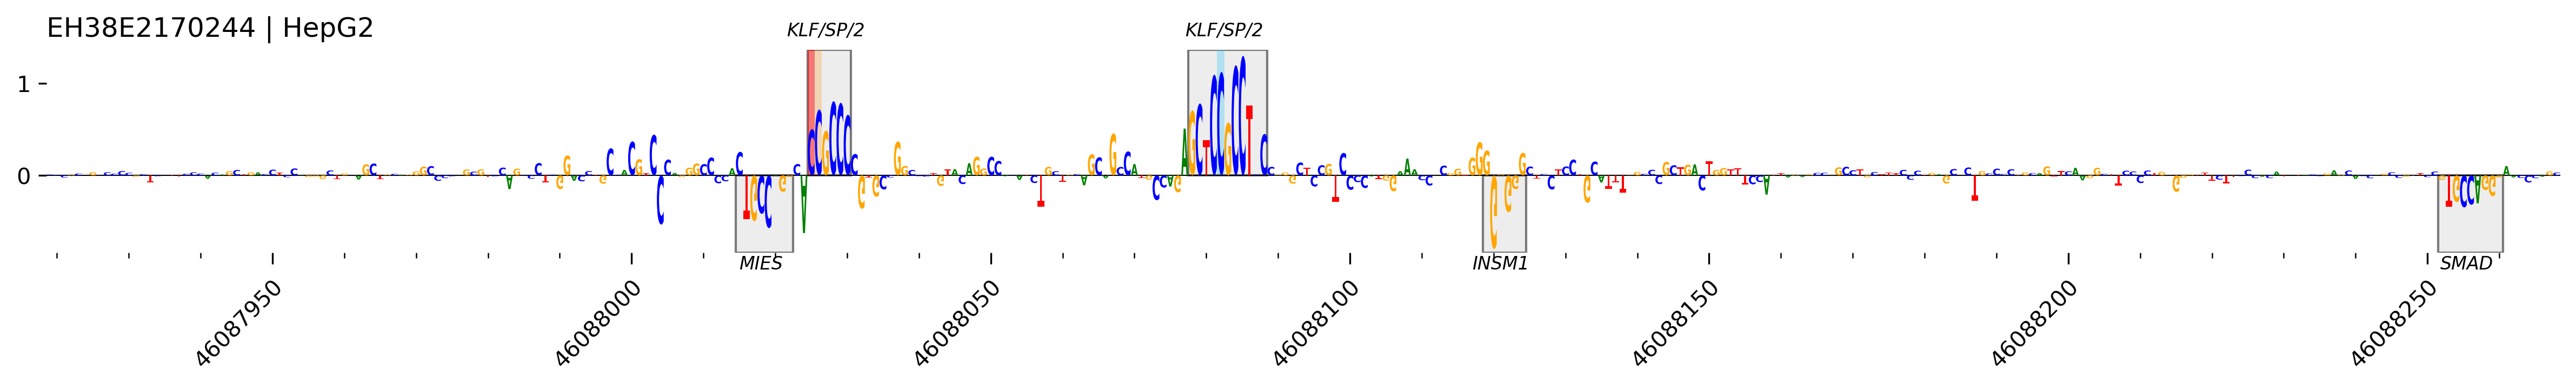

In [11]:
# EH38E2170244
plot_specific_enhancers_v2(
    'EH38E2170244',
    46087918,
    'chr22',
    h_mpac_collapsed_dels,
    openTargetsPaddedSummary,
    {'cell_type' : 'hepg2',
    'enhancer_id' : 'EH38E2170244',
    'phenotype' : 'Height, inverse-rank normalized'},
    'GWAS',
    'HepG2',
)

Saved plot: plot_outputs/EH38E2170244_K562_GWAS_logo.pdf
Saved summary: plot_outputs/EH38E2170244_K562_GWAS_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,openTargets_id,...,studyId,traitFromSource,posteriorProbability,is95CredibleSet,finemappingMethod,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
3101,chr22:46088019:C:T,chr22,46088019,C,T,k562,1.204024,EH38E2170244,True,22_46088019_C_T,...,FINNGEN_R12_HEIGHT_IRN,"Height, inverse-rank normalized",0.988219,True,SuSie,1.204024,0.600367,1.347688,2.244773,True
3106,chr22:46088025:C:T,chr22,46088025,C,T,k562,-0.600367,EH38E2170244,True,22_46088025_C_T,...,FINNGEN_R12_HEIGHT_IRN,"Height, inverse-rank normalized",0.988219,True,SuSie,0.600367,0.600367,1.347688,2.244773,False


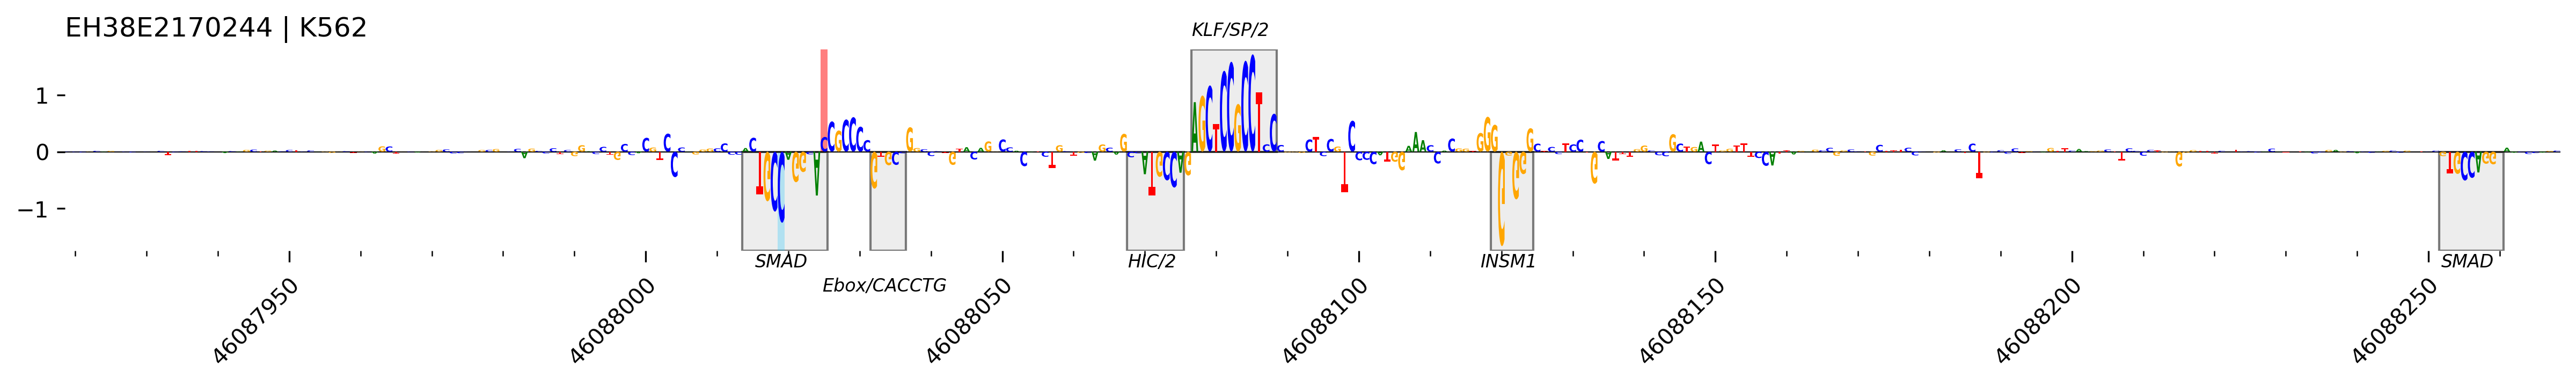

In [12]:
# EH38E2170244
plot_specific_enhancers_v2(
    'EH38E2170244',
    46087918,
    'chr22',
    k_mpac_collapsed_dels,
    openTargetsPaddedSummary,
    {'cell_type' : 'k562',
    'enhancer_id' : 'EH38E2170244',
    'phenotype' : 'Height, inverse-rank normalized'},
    'GWAS',
    'K562',
)

Saved plot: plot_outputs/EH38E1314911_K562_GWAS_logo.pdf
Saved summary: plot_outputs/EH38E1314911_K562_GWAS_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,openTargets_id,...,studyId,traitFromSource,posteriorProbability,is95CredibleSet,finemappingMethod,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
2155,chr1:6917291:C:T,chr1,6917291,C,T,k562,-0.536360,EH38E1314911,True,1_6917291_C_T,...,GCST90480644,Personal history of allergy to medicinal agent...,1.0,True,PICS,0.536360,0.53636,1.639042,3.055862,False
2156,chr1:6917292:G:A,chr1,6917292,G,A,k562,-1.151762,EH38E1314911,True,1_6917292_G_A,...,GCST90480644,Personal history of allergy to medicinal agent...,1.0,True,PICS,1.151762,0.53636,1.639042,3.055862,True
2164,chr1:6917307:G:A,chr1,6917307,G,A,k562,1.639042,EH38E1314911,True,1_6917307_G_A,...,GCST90480644,Personal history of allergy to medicinal agent...,1.0,True,PICS,1.639042,0.53636,1.639042,3.055862,True


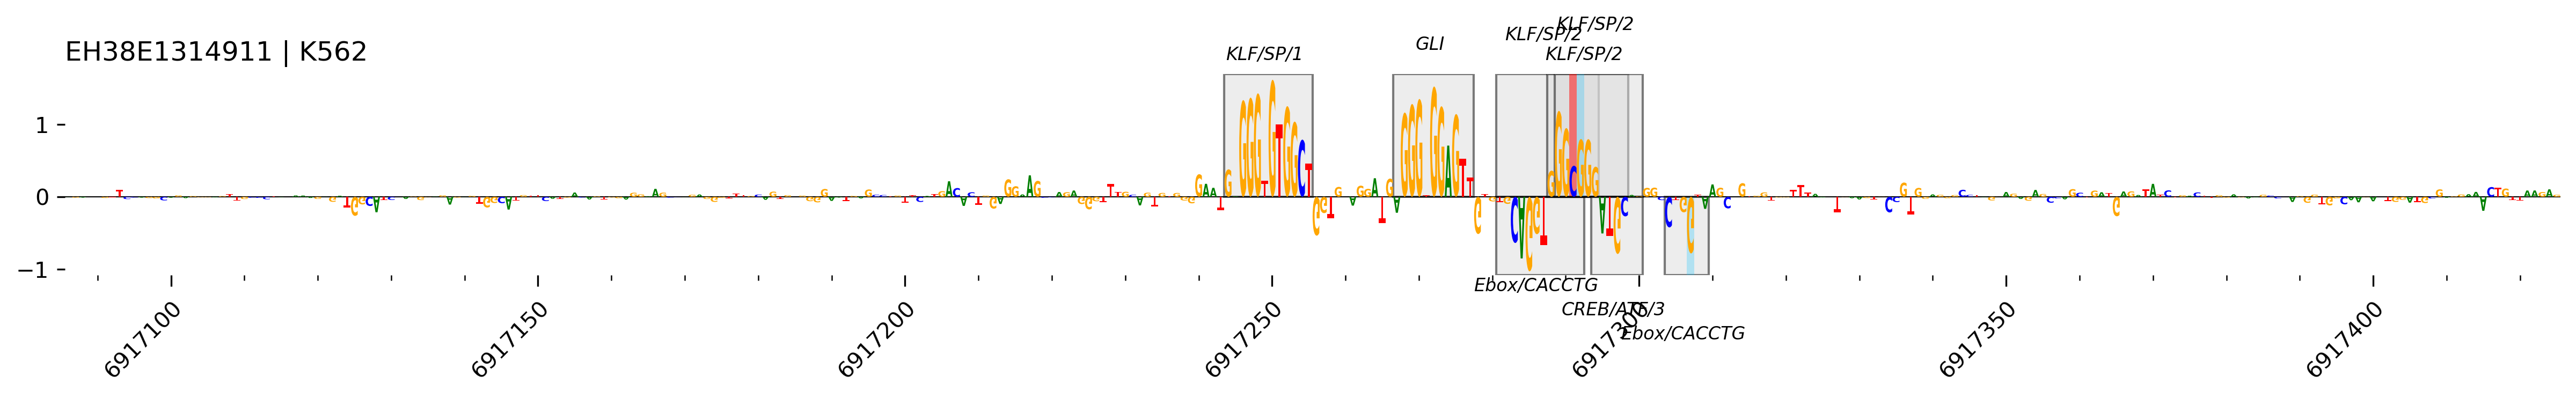

In [22]:
# EH38E1314911 GWAS variant
# chr1:6,917,085-6,917,425
# high delta lead variant
# identified in K562
# Ebox/CACCCTG motif
# 'Personal history of allergy to medicinal agents (PheCode 977)'
plot_specific_enhancers_v2(
    'EH38E1314911',
    6917085,
    'chr1',
    k_mpac_collapsed_dels,
    openTargetsPaddedSummary,
    {'cell_type' : 'k562',
    'enhancer_id' : 'EH38E1314911',
    'phenotype' : 'Personal history of allergy to medicinal agents (PheCode 977)'},
    'GWAS',
    'K562',
)

Saved plot: plot_outputs/EH38E2942188_K562_GWAS_logo.pdf
Saved summary: plot_outputs/EH38E2942188_K562_GWAS_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,openTargets_id,...,studyId,traitFromSource,posteriorProbability,is95CredibleSet,finemappingMethod,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
7263,chr11:6316291:C:A,chr11,6316291,C,A,k562,-0.518901,EH38E2942188,True,11_6316291_C_A,...,GCST90612823,Platelet endothelial cell adhesion molecule pr...,0.999998,True,SuSiE-inf,0.518901,0.518901,1.919974,3.700081,False
7274,chr11:6316295:T:C,chr11,6316295,T,C,k562,-1.919974,EH38E2942188,True,11_6316295_T_C,...,GCST90612823,Platelet endothelial cell adhesion molecule pr...,0.999998,True,SuSiE-inf,1.919974,0.518901,1.919974,3.700081,True
7277,chr11:6316296:C:G,chr11,6316296,C,G,k562,-1.428349,EH38E2942188,True,11_6316296_C_G,...,GCST90612823,Platelet endothelial cell adhesion molecule pr...,0.999998,True,SuSiE-inf,1.428349,0.518901,1.919974,3.700081,True


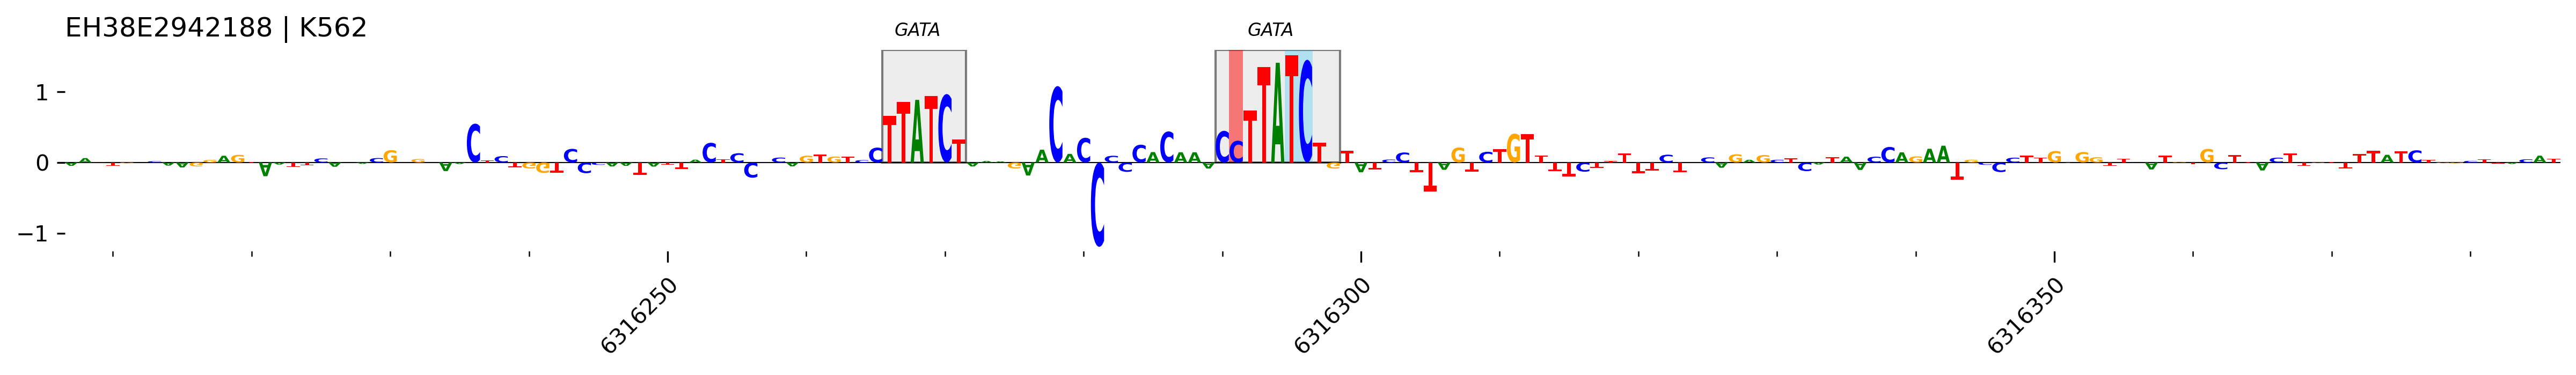

In [15]:
# EH38E2942188 GWAS variant
# chr11:6,316,206-6,316,386
# high delta lead variant
# identified in K562
# 'Platelet endothelial cell adhesion molecule protein level'
# identified in GATA motif
plot_specific_enhancers_v2(
    'EH38E2942188',
    6316206,
    'chr11',
    k_mpac_collapsed_dels,
    openTargetsPaddedSummary,
    {'cell_type' : 'k562',
    'enhancer_id' : 'EH38E2942188',
    'phenotype' : 'Platelet endothelial cell adhesion molecule protein level'},
    'GWAS',
    'K562'
)

Saved plot: plot_outputs/EH38E3320001_K562_GWAS_logo.pdf
Saved summary: plot_outputs/EH38E3320001_K562_GWAS_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,openTargets_id,...,studyId,traitFromSource,posteriorProbability,is95CredibleSet,finemappingMethod,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
7489,chr2:1496343:G:A,chr2,1496343,G,A,k562,-0.639347,EH38E3320001,True,2_1496343_G_A,...,GCST90479837,"Benign neoplasm of lip, oral cavity, and phary...",1.0,True,PICS,0.639347,1.082117,1.839837,1.70022,False
7491,chr2:1496343:G:T,chr2,1496343,G,T,k562,-0.910790,EH38E3320001,True,2_1496343_G_T,...,GCST90479837,"Benign neoplasm of lip, oral cavity, and phary...",1.0,True,PICS,0.910790,1.082117,1.839837,1.70022,False
7496,chr2:1496346:G:A,chr2,1496346,G,A,k562,-0.820530,EH38E3320001,True,2_1496346_G_A,...,GCST90479837,"Benign neoplasm of lip, oral cavity, and phary...",1.0,True,PICS,0.820530,1.082117,1.839837,1.70022,False
7498,chr2:1496346:G:T,chr2,1496346,G,T,k562,-0.528573,EH38E3320001,True,2_1496346_G_T,...,GCST90479837,"Benign neoplasm of lip, oral cavity, and phary...",1.0,True,PICS,0.528573,1.082117,1.839837,1.70022,False
7508,chr2:1496359:G:A,chr2,1496359,G,A,k562,-1.839837,EH38E3320001,True,2_1496359_G_A,...,GCST90479837,"Benign neoplasm of lip, oral cavity, and phary...",1.0,True,PICS,1.839837,1.082117,1.839837,1.70022,True
7513,chr2:1496360:C:T,chr2,1496360,C,T,k562,-0.682067,EH38E3320001,True,2_1496360_C_T,...,GCST90479837,"Benign neoplasm of lip, oral cavity, and phary...",1.0,True,PICS,0.682067,1.082117,1.839837,1.70022,False
7514,chr2:1496361:G:A,chr2,1496361,G,A,k562,-1.082117,EH38E3320001,True,2_1496361_G_A,...,GCST90479837,"Benign neoplasm of lip, oral cavity, and phary...",1.0,True,PICS,1.082117,1.082117,1.839837,1.70022,False


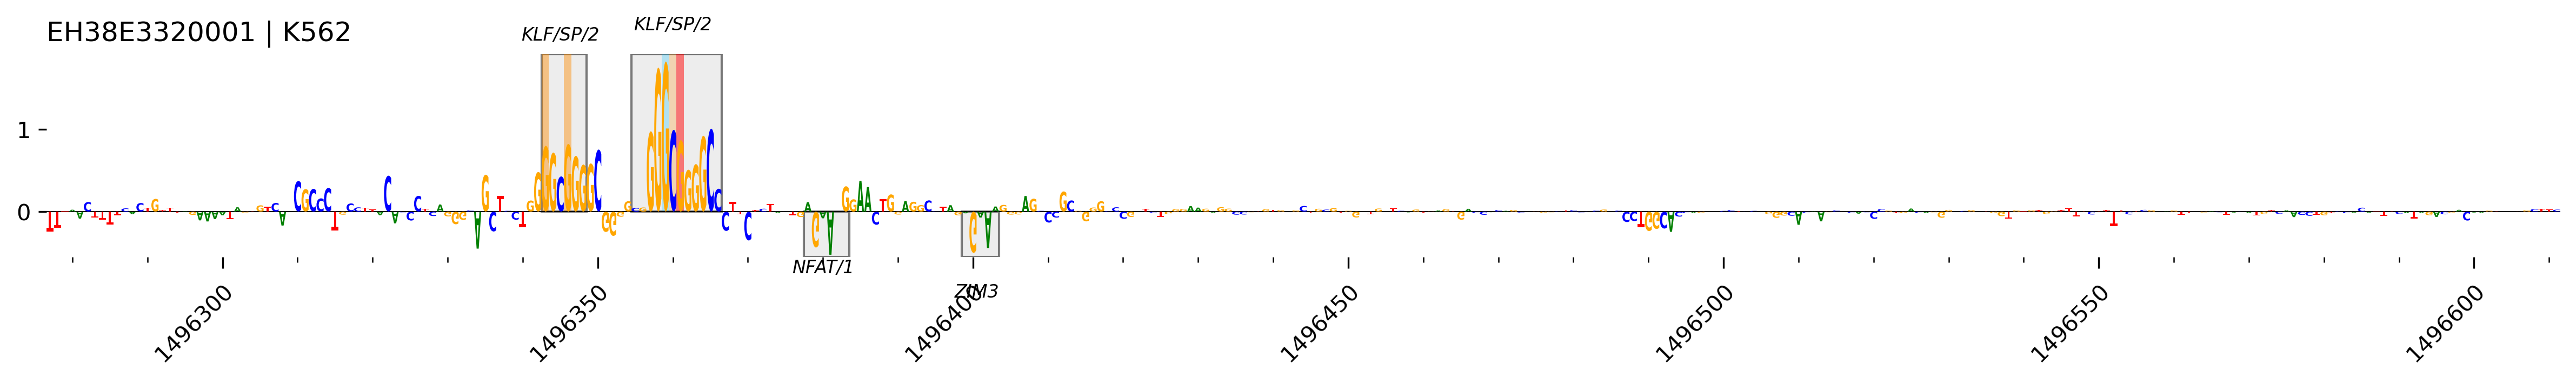

In [21]:
# EH38E3320001
# chr2:1,496,276-1,496,611
# high delta lead variant
# 'Benign neoplasm of lip, oral cavity, and pharynx (PheCode 210)'
plot_specific_enhancers_v2(
    'EH38E3320001',
    1496276,
    'chr2',
    k_mpac_collapsed_dels,
    openTargetsPaddedSummary,
    {'cell_type' : 'k562',
    'enhancer_id' : 'EH38E3320001',
    'phenotype' : 'Benign neoplasm of lip, oral cavity, and pharynx (PheCode 210)'},
    'GWAS',
    'K562'
)

Saved plot: plot_outputs/EH38E4423219_K562_GWAS_logo.pdf
Saved summary: plot_outputs/EH38E4423219_K562_GWAS_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,openTargets_id,...,studyId,traitFromSource,posteriorProbability,is95CredibleSet,finemappingMethod,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
32074,chr6:160012539:C:T,chr6,160012539,C,T,k562,-1.312027,EH38E4423219,True,6_160012539_C_T,...,GCST90480148,Other hypertrophic cardiomyopathy (PheCode 425...,1.0,True,PICS,1.312027,0.735476,1.512197,2.056078,True
32079,chr6:160012541:C:T,chr6,160012541,C,T,k562,-0.735476,EH38E4423219,True,6_160012541_C_T,...,GCST90480148,Other hypertrophic cardiomyopathy (PheCode 425...,1.0,True,PICS,0.735476,0.735476,1.512197,2.056078,False
32082,chr6:160012543:C:A,chr6,160012543,C,A,k562,-0.671779,EH38E4423219,True,6_160012543_C_A,...,GCST90480148,Other hypertrophic cardiomyopathy (PheCode 425...,1.0,True,PICS,0.671779,0.735476,1.512197,2.056078,False
32087,chr6:160012648:C:G,chr6,160012648,C,G,k562,-1.010185,EH38E4423219,True,6_160012648_C_G,...,GCST90480148,Other hypertrophic cardiomyopathy (PheCode 425...,1.0,True,PICS,1.010185,0.735476,1.512197,2.056078,True
32088,chr6:160012648:C:T,chr6,160012648,C,T,k562,-0.977602,EH38E4423219,True,6_160012648_C_T,...,GCST90480148,Other hypertrophic cardiomyopathy (PheCode 425...,1.0,True,PICS,0.977602,0.735476,1.512197,2.056078,True
32089,chr6:160012649:G:A,chr6,160012649,G,A,k562,-0.587327,EH38E4423219,True,6_160012649_G_A,...,GCST90480148,Other hypertrophic cardiomyopathy (PheCode 425...,1.0,True,PICS,0.587327,0.735476,1.512197,2.056078,False


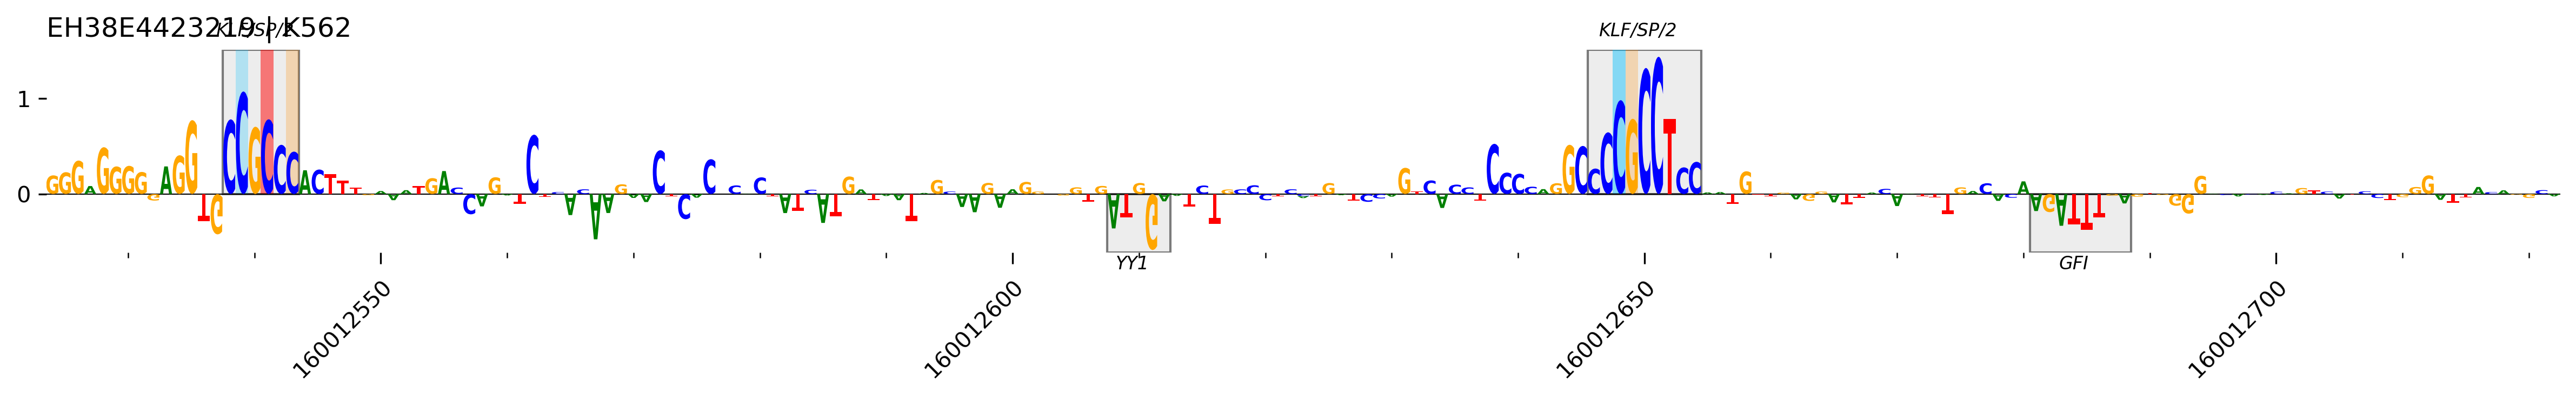

In [17]:
# EH38E4423219
# chr2
# 'Benign neoplasm of lip, oral cavity, and pharynx (PheCode 210)'
plot_specific_enhancers_v2(
    'EH38E4423219',
    160012523,
    'chr6',
    k_mpac_collapsed_dels,
    openTargetsPaddedSummary,
    {'cell_type' : 'k562',
    'enhancer_id' : 'EH38E4423219',
    'phenotype' : 'Other hypertrophic cardiomyopathy (PheCode 425.12)'},
    'GWAS',
    'K562'
)

Saved plot: plot_outputs/EH38E4436489_K562_GWAS_logo.pdf
Saved summary: plot_outputs/EH38E4436489_K562_GWAS_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,openTargets_id,...,studyId,traitFromSource,posteriorProbability,is95CredibleSet,finemappingMethod,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
32142,chr7:50197732:A:T,chr7,50197732,A,T,k562,-1.166605,EH38E4436489,True,7_50197732_A_T,...,GCST90609706,Serine/threonine-protein phosphatase 2A 56 kDa...,1.0,True,PICS,1.166605,1.091123,2.739042,2.510296,True
32144,chr7:50197733:T:C,chr7,50197733,T,C,k562,-1.970473,EH38E4436489,True,7_50197733_T_C,...,GCST90609706,Serine/threonine-protein phosphatase 2A 56 kDa...,1.0,True,PICS,1.970473,1.091123,2.739042,2.510296,True
32157,chr7:50197738:C:A,chr7,50197738,C,A,k562,-1.475959,EH38E4436489,True,7_50197738_C_A,...,GCST90609706,Serine/threonine-protein phosphatase 2A 56 kDa...,1.0,True,PICS,1.475959,1.091123,2.739042,2.510296,True
32159,chr7:50197738:C:T,chr7,50197738,C,T,k562,-2.397670,EH38E4436489,True,7_50197738_C_T,...,GCST90609706,Serine/threonine-protein phosphatase 2A 56 kDa...,1.0,True,PICS,2.397670,1.091123,2.739042,2.510296,True
32166,chr7:50197743:C:T,chr7,50197743,C,T,k562,-1.091123,EH38E4436489,True,7_50197743_C_T,...,GCST90609706,Serine/threonine-protein phosphatase 2A 56 kDa...,1.0,True,PICS,1.091123,1.091123,2.739042,2.510296,False


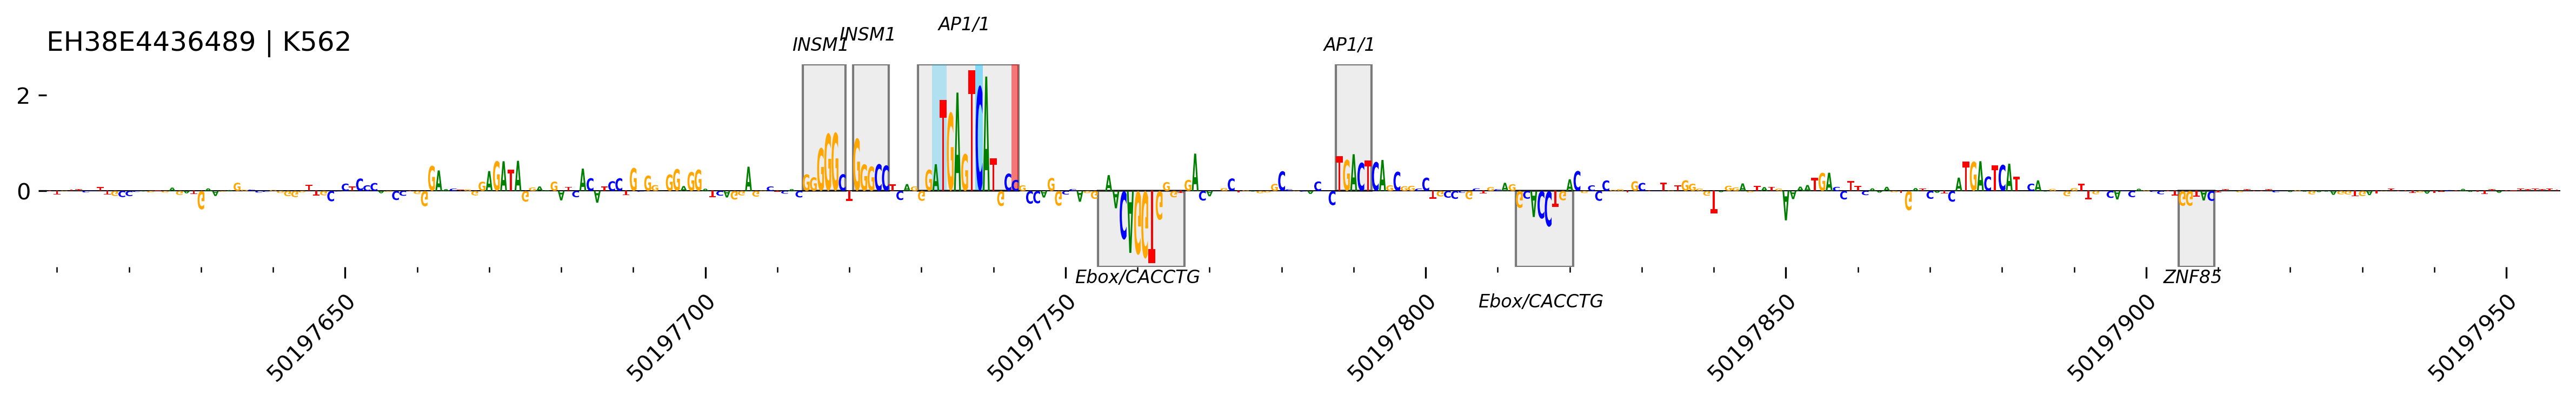

In [23]:
# EH38E4436489
# chr7:50,197,608-50,197,957
# 'Serine/threonine-protein phosphatase 2A 56 kDa regulatory subunit alpha isoform protein level'
plot_specific_enhancers_v2(
    'EH38E4436489',
    50197608,
    'chr7',
    k_mpac_collapsed_dels,
    openTargetsPaddedSummary,
    {'cell_type' : 'k562',
    'enhancer_id' : 'EH38E4436489',
    'phenotype' : 'Serine/threonine-protein phosphatase 2A 56 kDa regulatory subunit alpha isoform protein level'},
    'GWAS',
    'K562'
)

In [ ]:
### HEPG2 HIGH DELTAS ###

Saved plot: plot_outputs/EH38E3158486_HepG2_GWAS_logo.pdf
Saved summary: plot_outputs/EH38E3158486_HepG2_GWAS_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,openTargets_id,...,studyId,traitFromSource,posteriorProbability,is95CredibleSet,finemappingMethod,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
825,chr15:99508963:C:G,chr15,99508963,C,G,hepg2,-1.489496,EH38E3158486,True,15_99508963_C_G,...,GCST90454206,ICD10 E28.3: Primary ovarian failure,1.0,True,SuSiE-inf,1.489496,0.939276,1.567153,1.668468,True
833,chr15:99508966:A:G,chr15,99508966,A,G,hepg2,-0.939276,EH38E3158486,True,15_99508966_A_G,...,GCST90454206,ICD10 E28.3: Primary ovarian failure,1.0,True,SuSiE-inf,0.939276,0.939276,1.567153,1.668468,False
843,chr15:99508979:A:T,chr15,99508979,A,T,hepg2,0.542068,EH38E3158486,True,15_99508979_A_T,...,GCST90454206,ICD10 E28.3: Primary ovarian failure,1.0,True,SuSiE-inf,0.542068,0.939276,1.567153,1.668468,False
863,chr15:99509089:C:T,chr15,99509089,C,T,hepg2,-0.545715,EH38E3158486,True,15_99509089_C_T,...,GCST90454206,ICD10 E28.3: Primary ovarian failure,1.0,True,SuSiE-inf,0.545715,0.939276,1.567153,1.668468,False
866,chr15:99509091:T:A,chr15,99509091,T,A,hepg2,-1.174077,EH38E3158486,True,15_99509091_T_A,...,GCST90454206,ICD10 E28.3: Primary ovarian failure,1.0,True,SuSiE-inf,1.174077,0.939276,1.567153,1.668468,True
887,chr15:99509108:A:G,chr15,99509108,A,G,hepg2,-0.917054,EH38E3158486,True,15_99509108_A_G,...,GCST90454206,ICD10 E28.3: Primary ovarian failure,1.0,True,SuSiE-inf,0.917054,0.939276,1.567153,1.668468,False


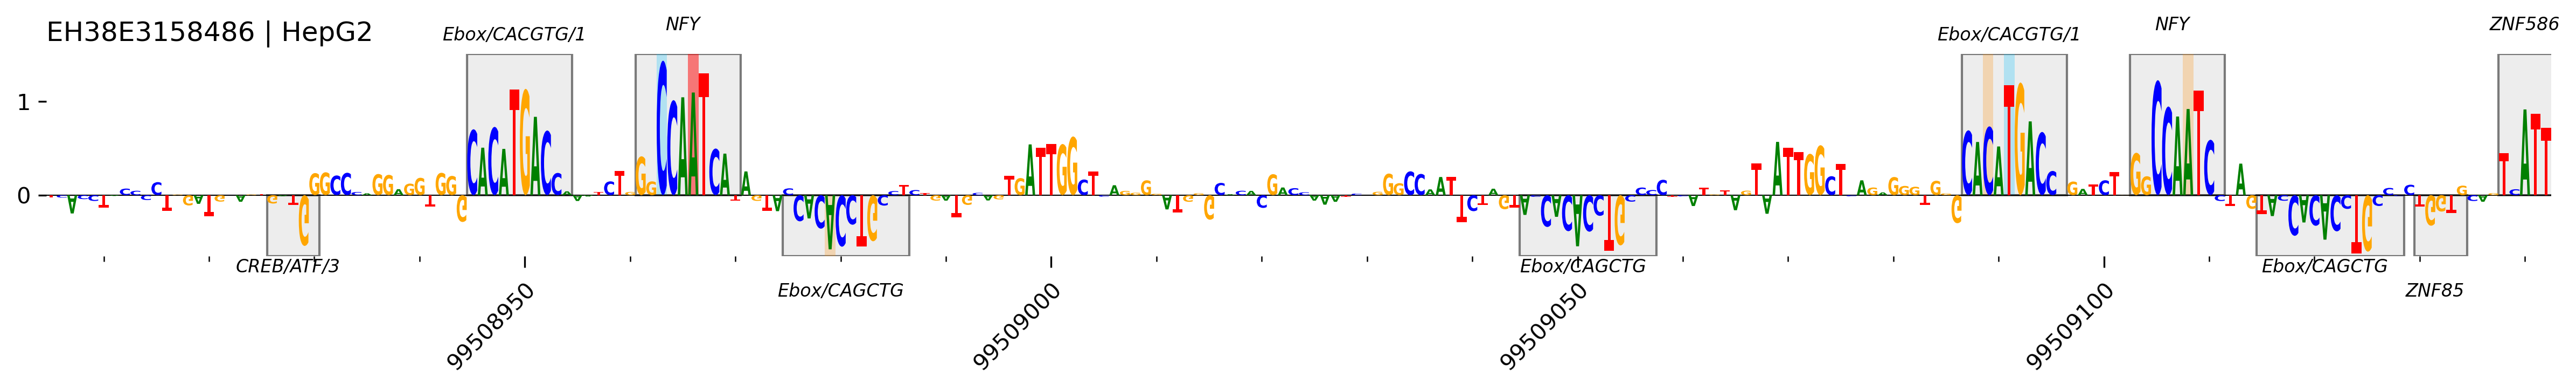

In [24]:
# EH38E3158486
# chr15:99,508,904-99,509,142
# lead Delta: 0.55
# 'ICD10 E28.3: Primary ovarian failure'
plot_specific_enhancers_v2(
    'EH38E3158486',
    99508904,
    'chr15',
    h_mpac_collapsed_dels,
    openTargetsPaddedSummary,
    {'cell_type' : 'hepg2',
    'enhancer_id' : 'EH38E3158486',
    'phenotype' : 'ICD10 E28.3: Primary ovarian failure'},
    'GWAS',
    'HepG2'
)

In [ ]:
### SKNSH HIGH DELTAS ###

Saved plot: plot_outputs/EH38E1517073_SKNSH_GWAS_logo.pdf
Saved summary: plot_outputs/EH38E1517073_SKNSH_GWAS_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,openTargets_id,...,studyId,traitFromSource,posteriorProbability,is95CredibleSet,finemappingMethod,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
32665,chr11:5564851:T:C,chr11,5564851,T,C,sknsh,-0.513440,EH38E1517073,True,11_5564851_T_C,...,GCST90475441,"mean corpuscular hemoglobin (MCH, maximum, inv...",0.999973,True,SuSiE-inf,0.513440,0.97643,2.758813,2.825409,False
32684,chr11:5564862:C:T,chr11,5564862,C,T,sknsh,-0.759996,EH38E1517073,True,11_5564862_C_T,...,GCST90475441,"mean corpuscular hemoglobin (MCH, maximum, inv...",0.999973,True,SuSiE-inf,0.759996,0.97643,2.758813,2.825409,False
32685,chr11:5564863:G:A,chr11,5564863,G,A,sknsh,-0.976430,EH38E1517073,True,11_5564863_G_A,...,GCST90475441,"mean corpuscular hemoglobin (MCH, maximum, inv...",0.999973,True,SuSiE-inf,0.976430,0.97643,2.758813,2.825409,False
32695,chr11:5564866:C:T,chr11,5564866,C,T,sknsh,-0.521366,EH38E1517073,True,11_5564866_C_T,...,GCST90475441,"mean corpuscular hemoglobin (MCH, maximum, inv...",0.999973,True,SuSiE-inf,0.521366,0.97643,2.758813,2.825409,False
32697,chr11:5564867:T:C,chr11,5564867,T,C,sknsh,-2.361169,EH38E1517073,True,11_5564867_T_C,...,GCST90475441,"mean corpuscular hemoglobin (MCH, maximum, inv...",0.999973,True,SuSiE-inf,2.361169,0.97643,2.758813,2.825409,True


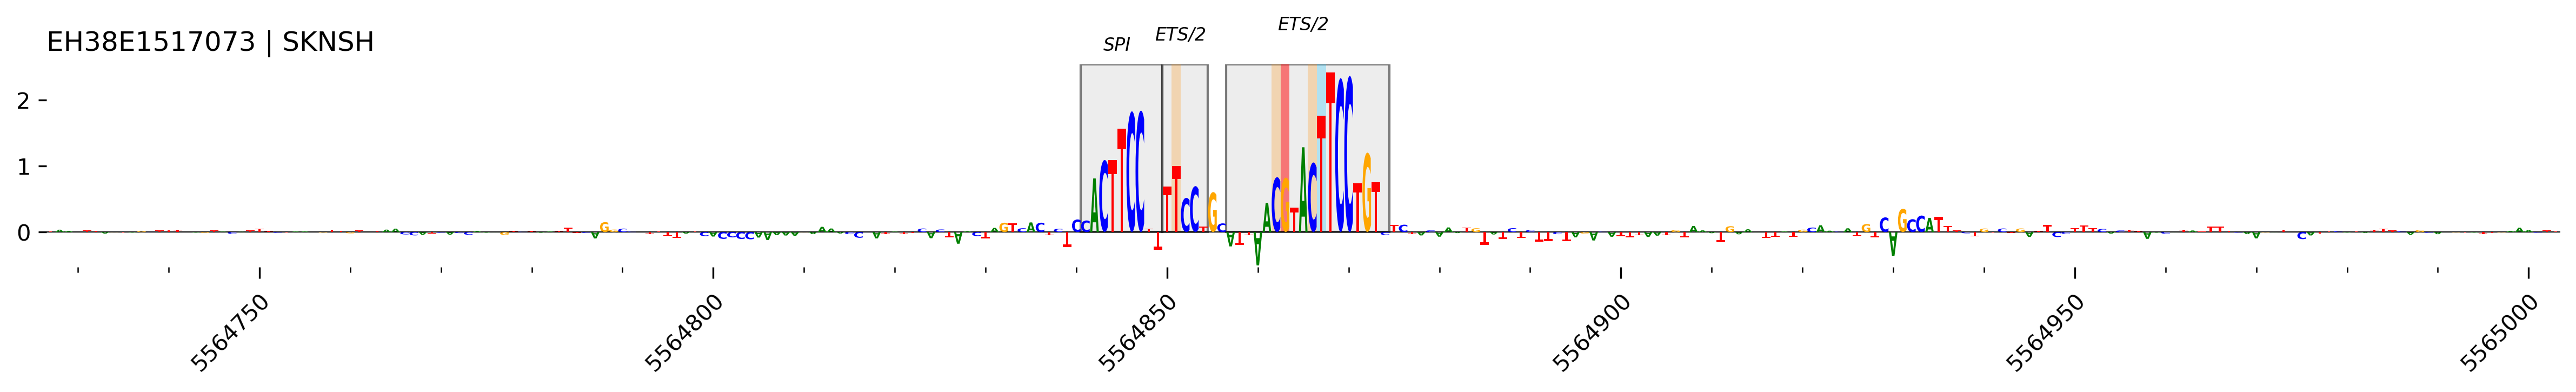

In [26]:
# EH38E1517073
# chr11:5,564,726-5,565,003
# lead delta: 1.38
# 'mean corpuscular hemoglobin (MCH, maximum, inv-norm transformed)'
plot_specific_enhancers_v2(
    'EH38E1517073',
    5564726,
    'chr11',
    s_mpac_collapsed_dels,
    openTargetsPaddedSummary,
    {'cell_type' : 'sknsh',
    'enhancer_id' : 'EH38E1517073',
    'phenotype' : 'mean corpuscular hemoglobin (MCH, maximum, inv-norm transformed)'},
    'GWAS',
    'SKNSH'
)


Saved plot: plot_outputs/EH38E2572340_SKNSH_GWAS_logo.pdf
Saved summary: plot_outputs/EH38E2572340_SKNSH_GWAS_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,openTargets_id,...,studyId,traitFromSource,posteriorProbability,is95CredibleSet,finemappingMethod,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
32984,chr7:94249765:C:A,chr7,94249765,C,A,sknsh,-0.787595,EH38E2572340,True,7_94249765_C_A,...,GCST90618070,Actin-binding LIM protein 3 protein level,1.0,True,PICS,0.787595,1.944448,2.779439,1.429423,False
32986,chr7:94249765:C:T,chr7,94249765,C,T,sknsh,-1.733489,EH38E2572340,True,7_94249765_C_T,...,GCST90618070,Actin-binding LIM protein 3 protein level,1.0,True,PICS,1.733489,1.944448,2.779439,1.429423,False
32988,chr7:94249766:T:C,chr7,94249766,T,C,sknsh,-0.979325,EH38E2572340,True,7_94249766_T_C,...,GCST90618070,Actin-binding LIM protein 3 protein level,1.0,True,PICS,0.979325,1.944448,2.779439,1.429423,False
32992,chr7:94249767:C:T,chr7,94249767,C,T,sknsh,-2.696614,EH38E2572340,True,7_94249767_C_T,...,GCST90618070,Actin-binding LIM protein 3 protein level,1.0,True,PICS,2.696614,1.944448,2.779439,1.429423,True
32993,chr7:94249768:G:A,chr7,94249768,G,A,sknsh,-1.944448,EH38E2572340,True,7_94249768_G_A,...,GCST90618070,Actin-binding LIM protein 3 protein level,1.0,True,PICS,1.944448,1.944448,2.779439,1.429423,False
32994,chr7:94249768:G:C,chr7,94249768,G,C,sknsh,-2.635363,EH38E2572340,True,7_94249768_G_C,...,GCST90618070,Actin-binding LIM protein 3 protein level,1.0,True,PICS,2.635363,1.944448,2.779439,1.429423,True
32998,chr7:94249770:G:A,chr7,94249770,G,A,sknsh,-2.010567,EH38E2572340,True,7_94249770_G_A,...,GCST90618070,Actin-binding LIM protein 3 protein level,1.0,True,PICS,2.010567,1.944448,2.779439,1.429423,True
33015,chr7:94249790:G:A,chr7,94249790,G,A,sknsh,-1.292901,EH38E2572340,True,7_94249790_G_A,...,GCST90618070,Actin-binding LIM protein 3 protein level,1.0,True,PICS,1.292901,1.944448,2.779439,1.429423,False
33017,chr7:94249790:G:T,chr7,94249790,G,T,sknsh,-1.364386,EH38E2572340,True,7_94249790_G_T,...,GCST90618070,Actin-binding LIM protein 3 protein level,1.0,True,PICS,1.364386,1.944448,2.779439,1.429423,False


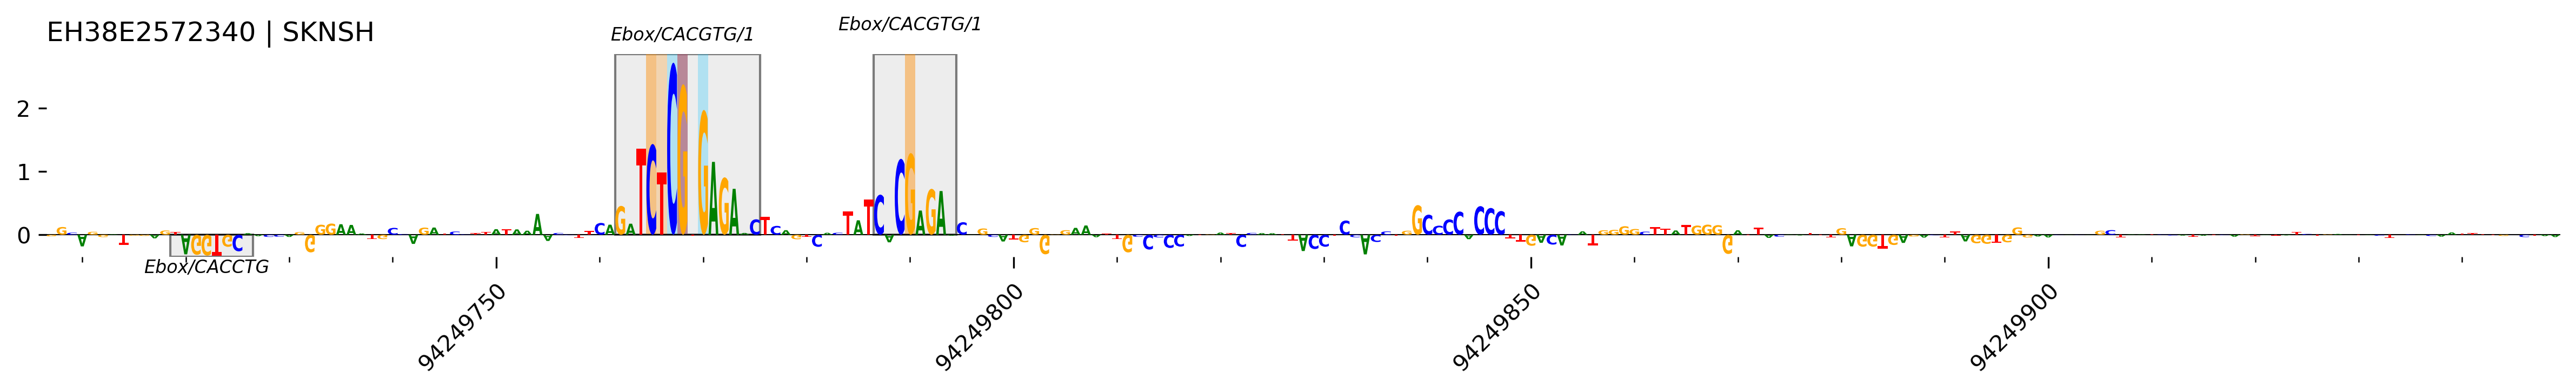

In [27]:
# EH38E2572340
# chr7:94,249,706-94,249,949
# lead delta: 0.75, 0.69
# 'Actin-binding LIM protein 3 protein level'
plot_specific_enhancers_v2(
    'EH38E2572340',
    94249706,
    'chr7',
    s_mpac_collapsed_dels,
    openTargetsPaddedSummary,
    {'cell_type' : 'sknsh',
    'enhancer_id' : 'EH38E2572340',
    'phenotype' : 'Actin-binding LIM protein 3 protein level'},
    'GWAS',
    'SKNSH'
)

Saved plot: plot_outputs/EH38E2778473_SKNSH_GWAS_logo.pdf
Saved summary: plot_outputs/EH38E2778473_SKNSH_GWAS_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,openTargets_id,...,studyId,traitFromSource,posteriorProbability,is95CredibleSet,finemappingMethod,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
33508,chr1:2180448:T:G,chr1,2180448,T,G,sknsh,-1.002523,EH38E2778473,True,1_2180448_T_G,...,GCST90475091,"Hemoglobin A1c (HbA1c, maximum, inv-norm trans...",0.99235,True,SuSiE-inf,1.002523,0.638428,1.433366,2.24515,True
33524,chr1:2180452:T:C,chr1,2180452,T,C,sknsh,-1.031071,EH38E2778473,True,1_2180452_T_C,...,GCST90475091,"Hemoglobin A1c (HbA1c, maximum, inv-norm trans...",0.99235,True,SuSiE-inf,1.031071,0.638428,1.433366,2.24515,True
33536,chr1:2180506:A:G,chr1,2180506,A,G,sknsh,-1.433366,EH38E2778473,True,1_2180506_A_G,...,GCST90475091,"Hemoglobin A1c (HbA1c, maximum, inv-norm trans...",0.99235,True,SuSiE-inf,1.433366,0.638428,1.433366,2.24515,True
33542,chr1:2180507:T:C,chr1,2180507,T,C,sknsh,-0.638428,EH38E2778473,True,1_2180507_T_C,...,GCST90475091,"Hemoglobin A1c (HbA1c, maximum, inv-norm trans...",0.99235,True,SuSiE-inf,0.638428,0.638428,1.433366,2.24515,False
33544,chr1:2180507:T:G,chr1,2180507,T,G,sknsh,-0.668191,EH38E2778473,True,1_2180507_T_G,...,GCST90475091,"Hemoglobin A1c (HbA1c, maximum, inv-norm trans...",0.99235,True,SuSiE-inf,0.668191,0.638428,1.433366,2.24515,True
33552,chr1:2180509:A:G,chr1,2180509,A,G,sknsh,-0.752414,EH38E2778473,True,1_2180509_A_G,...,GCST90475091,"Hemoglobin A1c (HbA1c, maximum, inv-norm trans...",0.99235,True,SuSiE-inf,0.752414,0.638428,1.433366,2.24515,True
33560,chr1:2180510:C:T,chr1,2180510,C,T,sknsh,-0.996712,EH38E2778473,True,1_2180510_C_T,...,GCST90475091,"Hemoglobin A1c (HbA1c, maximum, inv-norm trans...",0.99235,True,SuSiE-inf,0.996712,0.638428,1.433366,2.24515,True
33562,chr1:2180511:G:A,chr1,2180511,G,A,sknsh,-1.245030,EH38E2778473,True,1_2180511_G_A,...,GCST90475091,"Hemoglobin A1c (HbA1c, maximum, inv-norm trans...",0.99235,True,SuSiE-inf,1.245030,0.638428,1.433366,2.24515,True
33570,chr1:2180523:A:G,chr1,2180523,A,G,sknsh,-1.236996,EH38E2778473,True,1_2180523_A_G,...,GCST90475091,"Hemoglobin A1c (HbA1c, maximum, inv-norm trans...",0.99235,True,SuSiE-inf,1.236996,0.638428,1.433366,2.24515,True
33576,chr1:2180524:T:C,chr1,2180524,T,C,sknsh,-0.596238,EH38E2778473,True,1_2180524_T_C,...,GCST90475091,"Hemoglobin A1c (HbA1c, maximum, inv-norm trans...",0.99235,True,SuSiE-inf,0.596238,0.638428,1.433366,2.24515,False


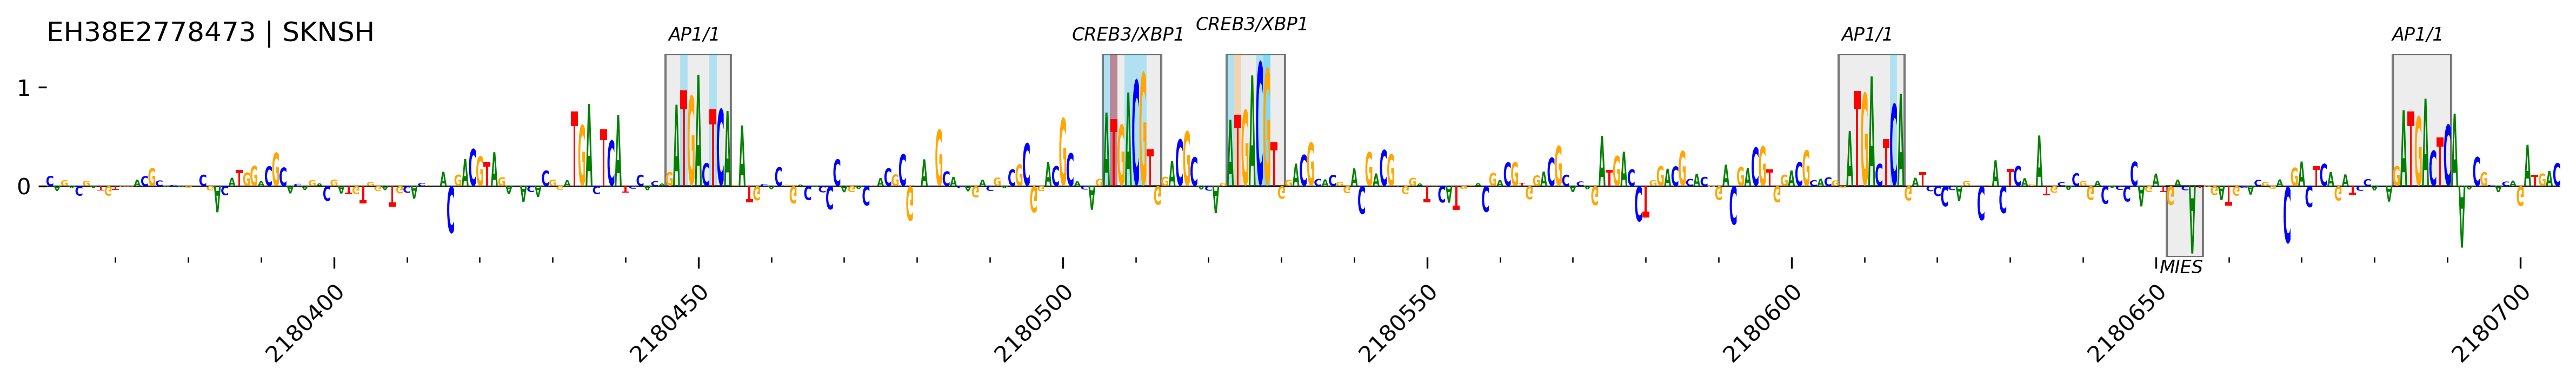

In [29]:
# EH38E2778473
# chr1:2,180,360-2,180,705
# lead Delta: 0.79, 0.6
# 'Hemoglobin A1c (HbA1c, maximum, inv-norm transformed)'
plot_specific_enhancers_v2(
    'EH38E2778473',
    2180360,
    'chr1',
    s_mpac_collapsed_dels,
    openTargetsPaddedSummary,
    {'cell_type' : 'sknsh',
    'enhancer_id' : 'EH38E2778473',
    'phenotype' : 'Hemoglobin A1c (HbA1c, maximum, inv-norm transformed)'},
    'GWAS',
    'SKNSH'
)

Saved plot: plot_outputs/EH38E2778473_SKNSH_GWAS_logo.pdf
Saved summary: plot_outputs/EH38E2778473_SKNSH_GWAS_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,openTargets_id,...,studyId,traitFromSource,posteriorProbability,is95CredibleSet,finemappingMethod,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
33509,chr1:2180448:T:G,chr1,2180448,T,G,sknsh,-1.002523,EH38E2778473,True,1_2180448_T_G,...,GCST90475094,"Hemoglobin A1c (HbA1c, mean, inv-norm transfor...",0.994379,True,SuSiE-inf,1.002523,0.638428,1.433366,2.24515,True
33525,chr1:2180452:T:C,chr1,2180452,T,C,sknsh,-1.031071,EH38E2778473,True,1_2180452_T_C,...,GCST90475094,"Hemoglobin A1c (HbA1c, mean, inv-norm transfor...",0.994379,True,SuSiE-inf,1.031071,0.638428,1.433366,2.24515,True
33537,chr1:2180506:A:G,chr1,2180506,A,G,sknsh,-1.433366,EH38E2778473,True,1_2180506_A_G,...,GCST90475094,"Hemoglobin A1c (HbA1c, mean, inv-norm transfor...",0.994379,True,SuSiE-inf,1.433366,0.638428,1.433366,2.24515,True
33543,chr1:2180507:T:C,chr1,2180507,T,C,sknsh,-0.638428,EH38E2778473,True,1_2180507_T_C,...,GCST90475094,"Hemoglobin A1c (HbA1c, mean, inv-norm transfor...",0.994379,True,SuSiE-inf,0.638428,0.638428,1.433366,2.24515,False
33545,chr1:2180507:T:G,chr1,2180507,T,G,sknsh,-0.668191,EH38E2778473,True,1_2180507_T_G,...,GCST90475094,"Hemoglobin A1c (HbA1c, mean, inv-norm transfor...",0.994379,True,SuSiE-inf,0.668191,0.638428,1.433366,2.24515,True
33553,chr1:2180509:A:G,chr1,2180509,A,G,sknsh,-0.752414,EH38E2778473,True,1_2180509_A_G,...,GCST90475094,"Hemoglobin A1c (HbA1c, mean, inv-norm transfor...",0.994379,True,SuSiE-inf,0.752414,0.638428,1.433366,2.24515,True
33561,chr1:2180510:C:T,chr1,2180510,C,T,sknsh,-0.996712,EH38E2778473,True,1_2180510_C_T,...,GCST90475094,"Hemoglobin A1c (HbA1c, mean, inv-norm transfor...",0.994379,True,SuSiE-inf,0.996712,0.638428,1.433366,2.24515,True
33563,chr1:2180511:G:A,chr1,2180511,G,A,sknsh,-1.245030,EH38E2778473,True,1_2180511_G_A,...,GCST90475094,"Hemoglobin A1c (HbA1c, mean, inv-norm transfor...",0.994379,True,SuSiE-inf,1.245030,0.638428,1.433366,2.24515,True
33571,chr1:2180523:A:G,chr1,2180523,A,G,sknsh,-1.236996,EH38E2778473,True,1_2180523_A_G,...,GCST90475094,"Hemoglobin A1c (HbA1c, mean, inv-norm transfor...",0.994379,True,SuSiE-inf,1.236996,0.638428,1.433366,2.24515,True
33577,chr1:2180524:T:C,chr1,2180524,T,C,sknsh,-0.596238,EH38E2778473,True,1_2180524_T_C,...,GCST90475094,"Hemoglobin A1c (HbA1c, mean, inv-norm transfor...",0.994379,True,SuSiE-inf,0.596238,0.638428,1.433366,2.24515,False


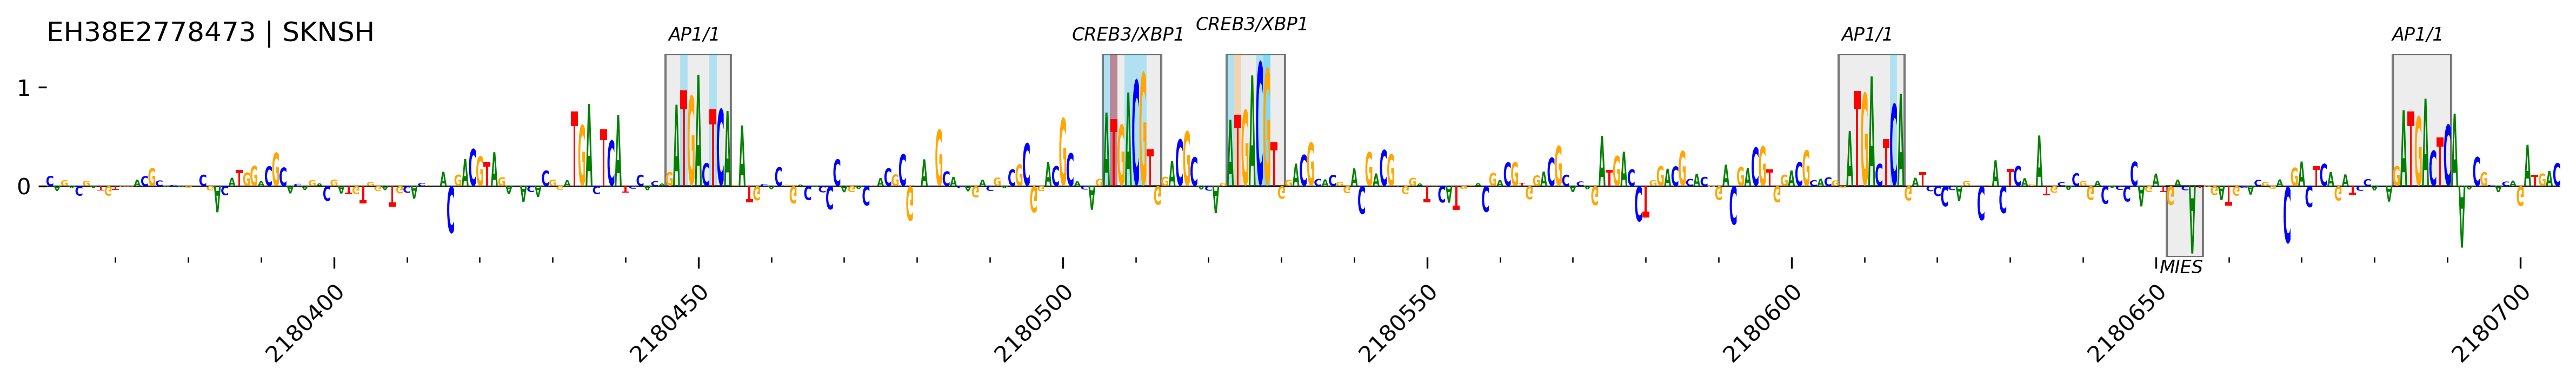

In [30]:
# EH38E2778473
# chr1:2,180,360-2,180,705
# lead Delta: 0.79, 0.6
# 'Hemoglobin A1c (HbA1c, mean, inv-norm transformed)'
plot_specific_enhancers_v2(
    'EH38E2778473',
    2180360,
    'chr1',
    s_mpac_collapsed_dels,
    openTargetsPaddedSummary,
    {'cell_type' : 'sknsh',
    'enhancer_id' : 'EH38E2778473',
    'phenotype' : 'Hemoglobin A1c (HbA1c, mean, inv-norm transformed)'},
    'GWAS',
    'SKNSH'
)

Saved plot: plot_outputs/EH38E2894846_SKNSH_GWAS_logo.pdf
Saved summary: plot_outputs/EH38E2894846_SKNSH_GWAS_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,openTargets_id,...,studyId,traitFromSource,posteriorProbability,is95CredibleSet,finemappingMethod,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
33791,chr10:32938598:G:A,chr10,32938598,G,A,sknsh,-1.381706,EH38E2894846,True,10_32938598_G_A,...,GCST90480080,Anisometropia (PheCode 368.3),1.0,True,PICS,1.381706,0.738293,2.425292,3.284998,True
33796,chr10:32938599:G:T,chr10,32938599,G,T,sknsh,-1.139454,EH38E2894846,True,10_32938599_G_T,...,GCST90480080,Anisometropia (PheCode 368.3),1.0,True,PICS,1.139454,0.738293,2.425292,3.284998,True
33807,chr10:32938612:C:T,chr10,32938612,C,T,sknsh,-0.738293,EH38E2894846,True,10_32938612_C_T,...,GCST90480080,Anisometropia (PheCode 368.3),1.0,True,PICS,0.738293,0.738293,2.425292,3.284998,False
33811,chr10:32938614:C:A,chr10,32938614,C,A,sknsh,-1.830825,EH38E2894846,True,10_32938614_C_A,...,GCST90480080,Anisometropia (PheCode 368.3),1.0,True,PICS,1.830825,0.738293,2.425292,3.284998,True
33813,chr10:32938614:C:T,chr10,32938614,C,T,sknsh,-2.270420,EH38E2894846,True,10_32938614_C_T,...,GCST90480080,Anisometropia (PheCode 368.3),1.0,True,PICS,2.270420,0.738293,2.425292,3.284998,True
33814,chr10:32938615:G:A,chr10,32938615,G,A,sknsh,-2.387032,EH38E2894846,True,10_32938615_G_A,...,GCST90480080,Anisometropia (PheCode 368.3),1.0,True,PICS,2.387032,0.738293,2.425292,3.284998,True
33818,chr10:32938616:G:C,chr10,32938616,G,C,sknsh,-2.324398,EH38E2894846,True,10_32938616_G_C,...,GCST90480080,Anisometropia (PheCode 368.3),1.0,True,PICS,2.324398,0.738293,2.425292,3.284998,True


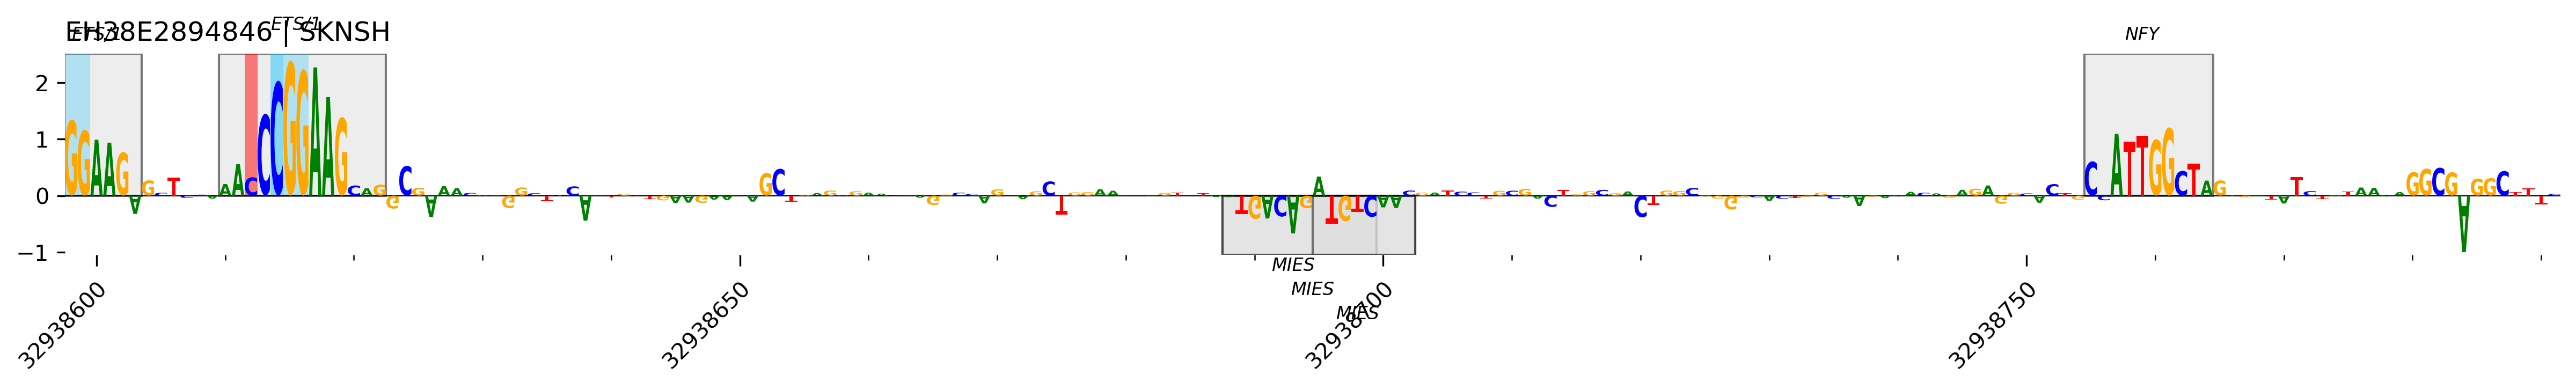

In [31]:
# EH38E2894846
# chr10:32,938,597-32,938,791
# delta Lead: 1.09, 1.53, 1.64, 1.59
# 'Anisometropia (PheCode 368.3)'
plot_specific_enhancers_v2(
    'EH38E2894846',
    32938597,
    'chr10',
    s_mpac_collapsed_dels,
    openTargetsPaddedSummary,
    {'cell_type' : 'sknsh',
    'enhancer_id' : 'EH38E2894846',
    'phenotype' : 'Anisometropia (PheCode 368.3)'},
    'GWAS',
    'SKNSH'
)

Saved plot: plot_outputs/EH38E3158486_SKNSH_GWAS_logo.pdf
Saved summary: plot_outputs/EH38E3158486_SKNSH_GWAS_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,openTargets_id,...,studyId,traitFromSource,posteriorProbability,is95CredibleSet,finemappingMethod,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
34097,chr15:99508963:C:G,chr15,99508963,C,G,sknsh,-1.955387,EH38E3158486,True,15_99508963_C_G,...,GCST90454206,ICD10 E28.3: Primary ovarian failure,1.0,True,SuSiE-inf,1.955387,1.309354,2.132314,1.628523,True
34106,chr15:99508966:A:G,chr15,99508966,A,G,sknsh,-1.309354,EH38E3158486,True,15_99508966_A_G,...,GCST90454206,ICD10 E28.3: Primary ovarian failure,1.0,True,SuSiE-inf,1.309354,1.309354,2.132314,1.628523,False
34122,chr15:99508979:A:T,chr15,99508979,A,T,sknsh,1.708121,EH38E3158486,True,15_99508979_A_T,...,GCST90454206,ICD10 E28.3: Primary ovarian failure,1.0,True,SuSiE-inf,1.708121,1.309354,2.132314,1.628523,True
34125,chr15:99508980:C:T,chr15,99508980,C,T,sknsh,1.623956,EH38E3158486,True,15_99508980_C_T,...,GCST90454206,ICD10 E28.3: Primary ovarian failure,1.0,True,SuSiE-inf,1.623956,1.309354,2.132314,1.628523,True
34128,chr15:99508981:C:T,chr15,99508981,C,T,sknsh,1.593342,EH38E3158486,True,15_99508981_C_T,...,GCST90454206,ICD10 E28.3: Primary ovarian failure,1.0,True,SuSiE-inf,1.593342,1.309354,2.132314,1.628523,True
34149,chr15:99509002:G:A,chr15,99509002,G,A,sknsh,-0.805235,EH38E3158486,True,15_99509002_G_A,...,GCST90454206,ICD10 E28.3: Primary ovarian failure,1.0,True,SuSiE-inf,0.805235,1.309354,2.132314,1.628523,False
34168,chr15:99509054:G:A,chr15,99509054,G,A,sknsh,1.033820,EH38E3158486,True,15_99509054_G_A,...,GCST90454206,ICD10 E28.3: Primary ovarian failure,1.0,True,SuSiE-inf,1.033820,1.309354,2.132314,1.628523,False
34176,chr15:99509070:T:C,chr15,99509070,T,C,sknsh,-0.624603,EH38E3158486,True,15_99509070_T_C,...,GCST90454206,ICD10 E28.3: Primary ovarian failure,1.0,True,SuSiE-inf,0.624603,1.309354,2.132314,1.628523,False
34196,chr15:99509089:C:T,chr15,99509089,C,T,sknsh,-0.656540,EH38E3158486,True,15_99509089_C_T,...,GCST90454206,ICD10 E28.3: Primary ovarian failure,1.0,True,SuSiE-inf,0.656540,1.309354,2.132314,1.628523,False
34199,chr15:99509091:T:A,chr15,99509091,T,A,sknsh,-1.316120,EH38E3158486,True,15_99509091_T_A,...,GCST90454206,ICD10 E28.3: Primary ovarian failure,1.0,True,SuSiE-inf,1.316120,1.309354,2.132314,1.628523,True


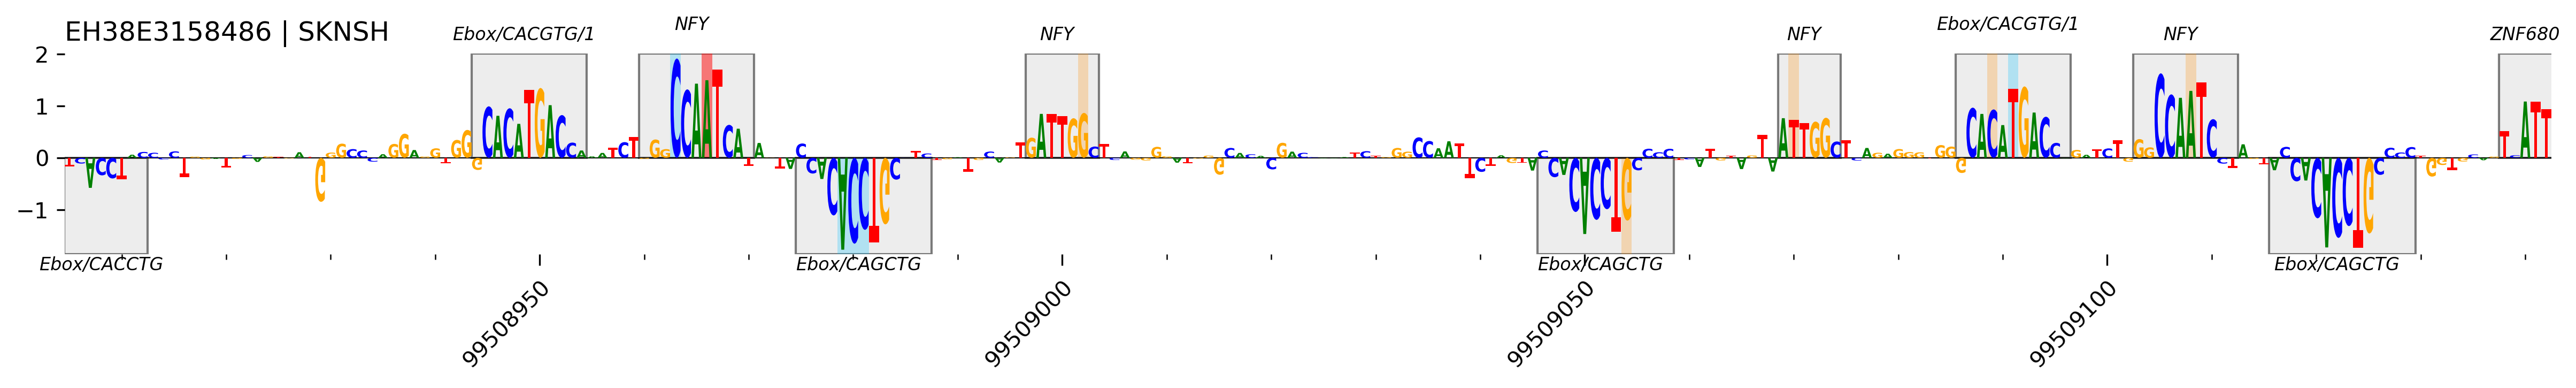

In [32]:
# EH38E3158486
# chr15:99,508,904-99,509,142
# lead Delta: 0.55
# 'ICD10 E28.3: Primary ovarian failure'
plot_specific_enhancers_v2(
    'EH38E3158486',
    99508904,
    'chr15',
    s_mpac_collapsed_dels,
    openTargetsPaddedSummary,
    {'cell_type' : 'sknsh',
    'enhancer_id' : 'EH38E3158486',
    'phenotype' : 'ICD10 E28.3: Primary ovarian failure'},
    'GWAS',
    'SKNSH'
)

Saved plot: plot_outputs/EH38E3280529_SKNSH_GWAS_logo.pdf
Saved summary: plot_outputs/EH38E3280529_SKNSH_GWAS_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,openTargets_id,...,studyId,traitFromSource,posteriorProbability,is95CredibleSet,finemappingMethod,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
34259,chr19:1217553:C:T,chr19,1217553,C,T,sknsh,-0.691134,EH38E3280529,True,19_1217553_C_T,...,GCST90476338,"heart rate (HR, mean, inv-normal transformed)",0.919308,True,SuSiE-inf,0.691134,0.56987,1.3109,2.30035,True
34263,chr19:1217557:T:A,chr19,1217557,T,A,sknsh,0.544276,EH38E3280529,True,19_1217557_T_A,...,GCST90476338,"heart rate (HR, mean, inv-normal transformed)",0.919308,True,SuSiE-inf,0.544276,0.56987,1.3109,2.30035,False
34267,chr19:1217560:G:A,chr19,1217560,G,A,sknsh,-1.107630,EH38E3280529,True,19_1217560_G_A,...,GCST90476338,"heart rate (HR, mean, inv-normal transformed)",0.919308,True,SuSiE-inf,1.107630,0.56987,1.3109,2.30035,True
34270,chr19:1217561:C:G,chr19,1217561,C,G,sknsh,-0.569870,EH38E3280529,True,19_1217561_C_G,...,GCST90476338,"heart rate (HR, mean, inv-normal transformed)",0.919308,True,SuSiE-inf,0.569870,0.56987,1.3109,2.30035,False
34271,chr19:1217562:G:A,chr19,1217562,G,A,sknsh,-0.912643,EH38E3280529,True,19_1217562_G_A,...,GCST90476338,"heart rate (HR, mean, inv-normal transformed)",0.919308,True,SuSiE-inf,0.912643,0.56987,1.3109,2.30035,True


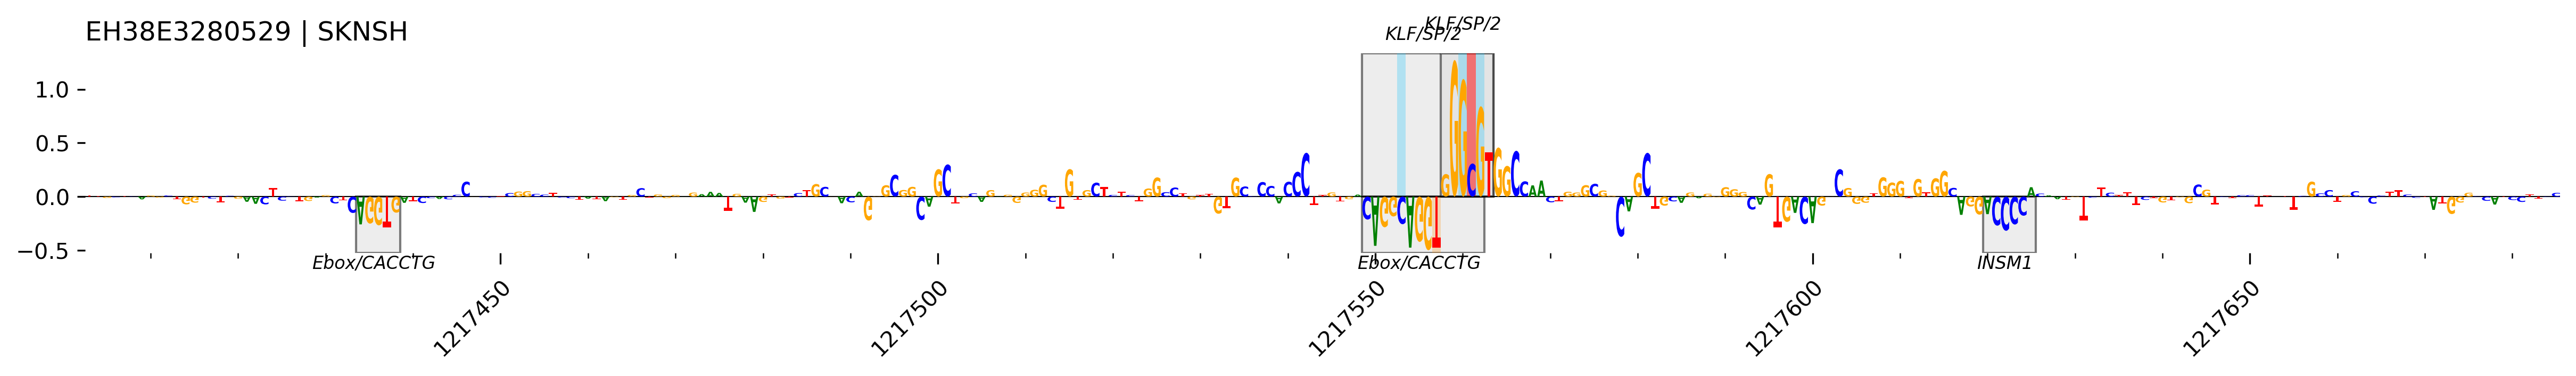

In [33]:
# EH38E3280529
# chr19:1,217,402-1,217,685
# lead Delta: 0.537760
# 'heart rate (HR, mean, inv-normal transformed)'
plot_specific_enhancers_v2(
    'EH38E3280529',
    1217402,
    'chr19',
    s_mpac_collapsed_dels,
    openTargetsPaddedSummary,
    {'cell_type' : 'sknsh',
    'enhancer_id' : 'EH38E3280529',
    'phenotype' : 'heart rate (HR, mean, inv-normal transformed)'},
    'GWAS',
    'SKNSH'
)

Saved plot: plot_outputs/EH38E3819299_SKNSH_GWAS_logo.pdf
Saved summary: plot_outputs/EH38E3819299_SKNSH_GWAS_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,openTargets_id,...,studyId,traitFromSource,posteriorProbability,is95CredibleSet,finemappingMethod,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
48333,chr8:16330798:T:G,chr8,16330798,T,G,sknsh,-2.107861,EH38E3819299,True,8_16330798_T_G,...,GCST90475658,Diabetes mellitus (PheCode 250),0.998887,True,SuSiE-inf,2.107861,1.181902,2.319249,1.962303,True
48335,chr8:16330799:G:A,chr8,16330799,G,A,sknsh,-2.155936,EH38E3819299,True,8_16330799_G_A,...,GCST90475658,Diabetes mellitus (PheCode 250),0.998887,True,SuSiE-inf,2.155936,1.181902,2.319249,1.962303,True
48347,chr8:16330801:G:A,chr8,16330801,G,A,sknsh,-1.181902,EH38E3819299,True,8_16330801_G_A,...,GCST90475658,Diabetes mellitus (PheCode 250),0.998887,True,SuSiE-inf,1.181902,1.181902,2.319249,1.962303,False
48381,chr8:16330805:A:C,chr8,16330805,A,C,sknsh,1.178628,EH38E3819299,True,8_16330805_A_C,...,GCST90475658,Diabetes mellitus (PheCode 250),0.998887,True,SuSiE-inf,1.178628,1.181902,2.319249,1.962303,False
48389,chr8:16330805:A:C,chr8,16330805,A,C,sknsh,1.178628,EH38E3819299,True,8_16330805_A_C,...,GCST90475658,Diabetes mellitus (PheCode 250),0.998887,True,SuSiE-inf,1.178628,1.181902,2.319249,1.962303,False
48435,chr8:16330815:A:C,chr8,16330815,A,C,sknsh,0.986904,EH38E3819299,True,8_16330815_A_C,...,GCST90475658,Diabetes mellitus (PheCode 250),0.998887,True,SuSiE-inf,0.986904,1.181902,2.319249,1.962303,False


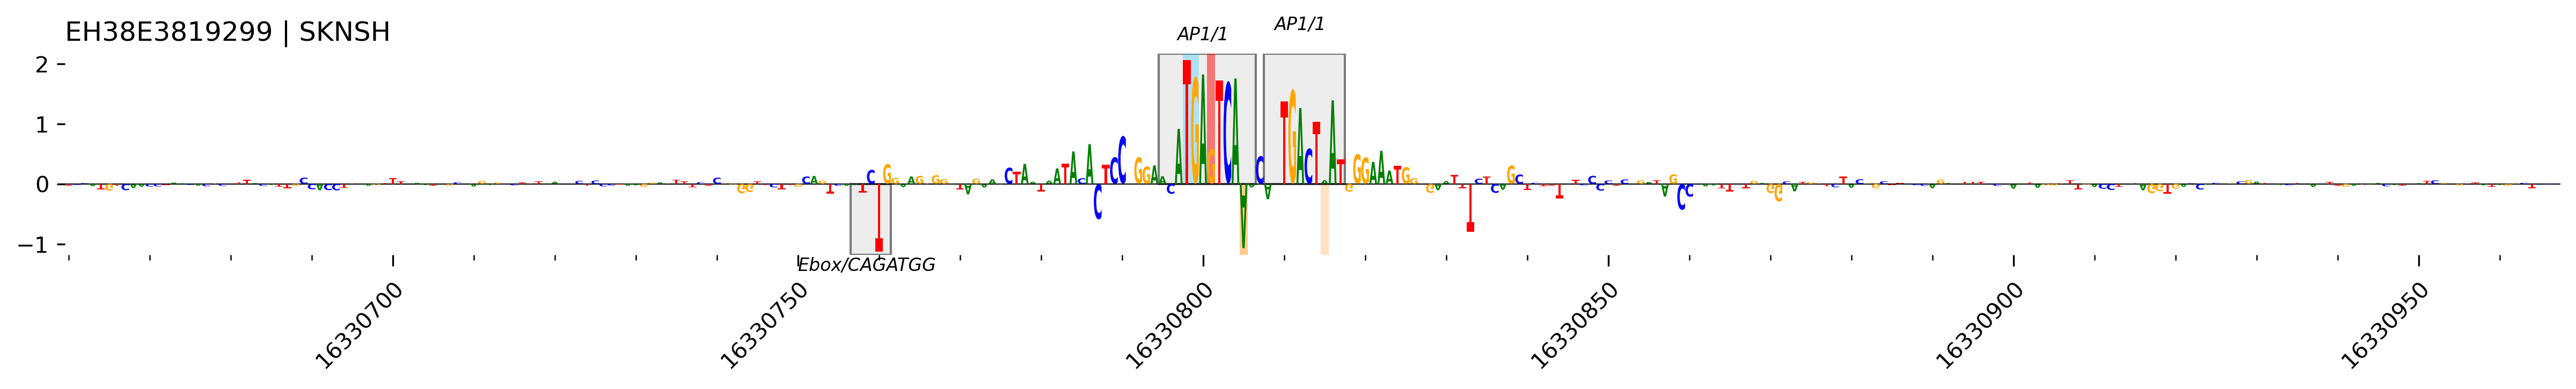

In [34]:
# EH38E3819299
# chr8:16,330,659-16,330,967
# lead Delta: 0.925959, 0.974034
# 'Diabetes mellitus (PheCode 250)'
plot_specific_enhancers_v2(
    'EH38E3819299',
    16330659,
    'chr8',
    s_mpac_collapsed_dels,
    openTargetsPaddedSummary,
    {'cell_type' : 'sknsh',
    'enhancer_id' : 'EH38E3819299',
    'phenotype' : 'Diabetes mellitus (PheCode 250)'},
    'GWAS',
    'SKNSH'
)

Saved plot: plot_outputs/EH38E3819299_SKNSH_GWAS_logo.pdf
Saved summary: plot_outputs/EH38E3819299_SKNSH_GWAS_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,openTargets_id,...,studyId,traitFromSource,posteriorProbability,is95CredibleSet,finemappingMethod,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
48334,chr8:16330798:T:G,chr8,16330798,T,G,sknsh,-2.107861,EH38E3819299,True,8_16330798_T_G,...,GCST90475667,Type 2 diabetes (PheCode 250.2),0.998827,True,SuSiE-inf,2.107861,1.181902,2.319249,1.962303,True
48336,chr8:16330799:G:A,chr8,16330799,G,A,sknsh,-2.155936,EH38E3819299,True,8_16330799_G_A,...,GCST90475667,Type 2 diabetes (PheCode 250.2),0.998827,True,SuSiE-inf,2.155936,1.181902,2.319249,1.962303,True
48348,chr8:16330801:G:A,chr8,16330801,G,A,sknsh,-1.181902,EH38E3819299,True,8_16330801_G_A,...,GCST90475667,Type 2 diabetes (PheCode 250.2),0.998827,True,SuSiE-inf,1.181902,1.181902,2.319249,1.962303,False
48382,chr8:16330805:A:C,chr8,16330805,A,C,sknsh,1.178628,EH38E3819299,True,8_16330805_A_C,...,GCST90475667,Type 2 diabetes (PheCode 250.2),0.998827,True,SuSiE-inf,1.178628,1.181902,2.319249,1.962303,False
48390,chr8:16330805:A:C,chr8,16330805,A,C,sknsh,1.178628,EH38E3819299,True,8_16330805_A_C,...,GCST90475667,Type 2 diabetes (PheCode 250.2),0.998827,True,SuSiE-inf,1.178628,1.181902,2.319249,1.962303,False
48436,chr8:16330815:A:C,chr8,16330815,A,C,sknsh,0.986904,EH38E3819299,True,8_16330815_A_C,...,GCST90475667,Type 2 diabetes (PheCode 250.2),0.998827,True,SuSiE-inf,0.986904,1.181902,2.319249,1.962303,False


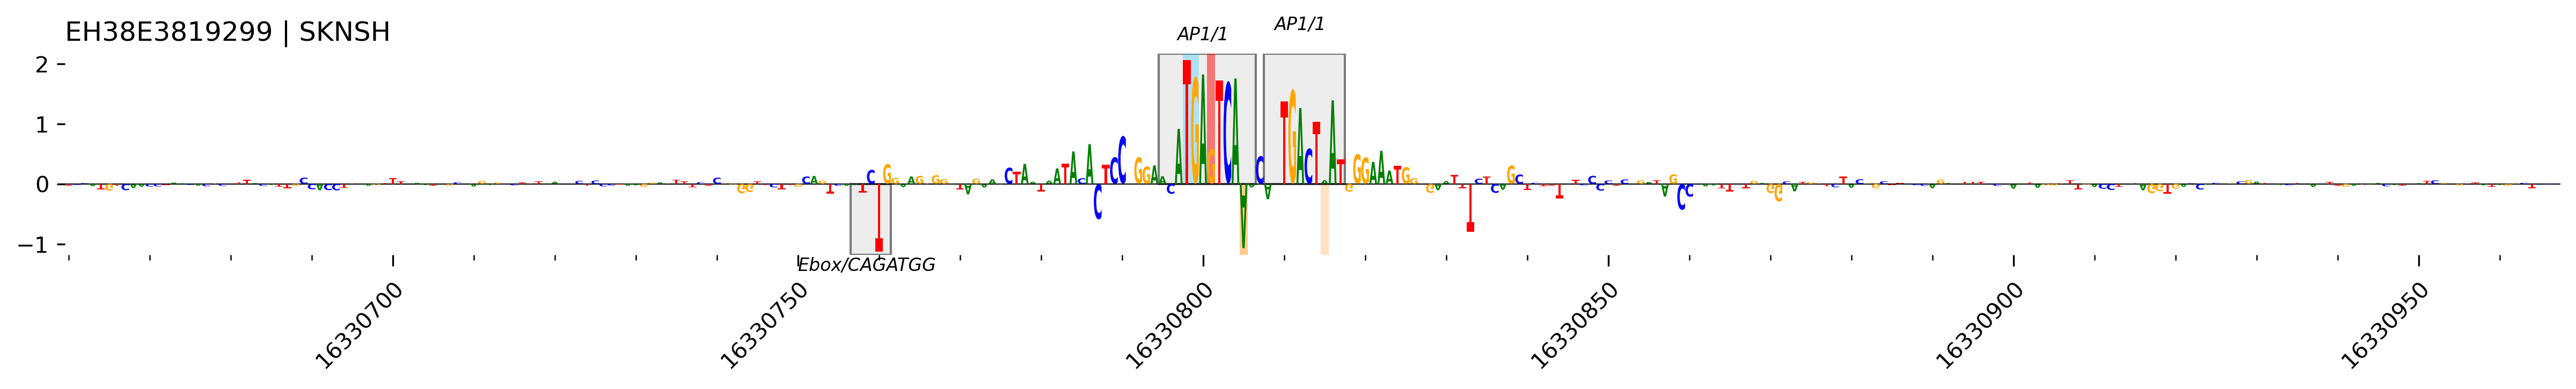

In [35]:
# EH38E3819299
# chr8:16,330,659-16,330,967
# lead Delta: 0.925959, 0.974034
# 'Type 2 diabetes (PheCode 250.2)'
plot_specific_enhancers_v2(
    'EH38E3819299',
    16330659,
    'chr8',
    s_mpac_collapsed_dels,
    openTargetsPaddedSummary,
    {'cell_type' : 'sknsh',
    'enhancer_id' : 'EH38E3819299',
    'phenotype' : 'Type 2 diabetes (PheCode 250.2)'},
    'GWAS',
    'SKNSH'
)

In [ ]:
### K562 GTEx HIGH DELTAS ###

Saved plot: plot_outputs/EH38E3776679_K562_GTEx_logo.pdf
Saved summary: plot_outputs/EH38E3776679_K562_GTEx_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,gtex_id,...,af_eqtl,afc,afc_se,cs_id,cs_size,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
4172,chr7:65731813:T:C,chr7,65731813,T,C,k562,-0.528722,EH38E3776679,True,chr7_65731813_T_C_b38,...,0.839754,-0.745597,0.103113,2,1,0.528722,0.528722,2.327588,4.402293,False
4190,chr7:65731820:G:C,chr7,65731820,G,C,k562,-1.970768,EH38E3776679,True,chr7_65731820_G_C_b38,...,0.839754,-0.745597,0.103113,2,1,1.970768,0.528722,2.327588,4.402293,True
4197,chr7:65731822:C:T,chr7,65731822,C,T,k562,-2.242539,EH38E3776679,True,chr7_65731822_C_T_b38,...,0.839754,-0.745597,0.103113,2,1,2.242539,0.528722,2.327588,4.402293,True
4200,chr7:65731822:C:T,chr7,65731822,C,T,k562,-2.242539,EH38E3776679,True,chr7_65731822_C_T_b38,...,0.839754,-0.745597,0.103113,2,1,2.242539,0.528722,2.327588,4.402293,True


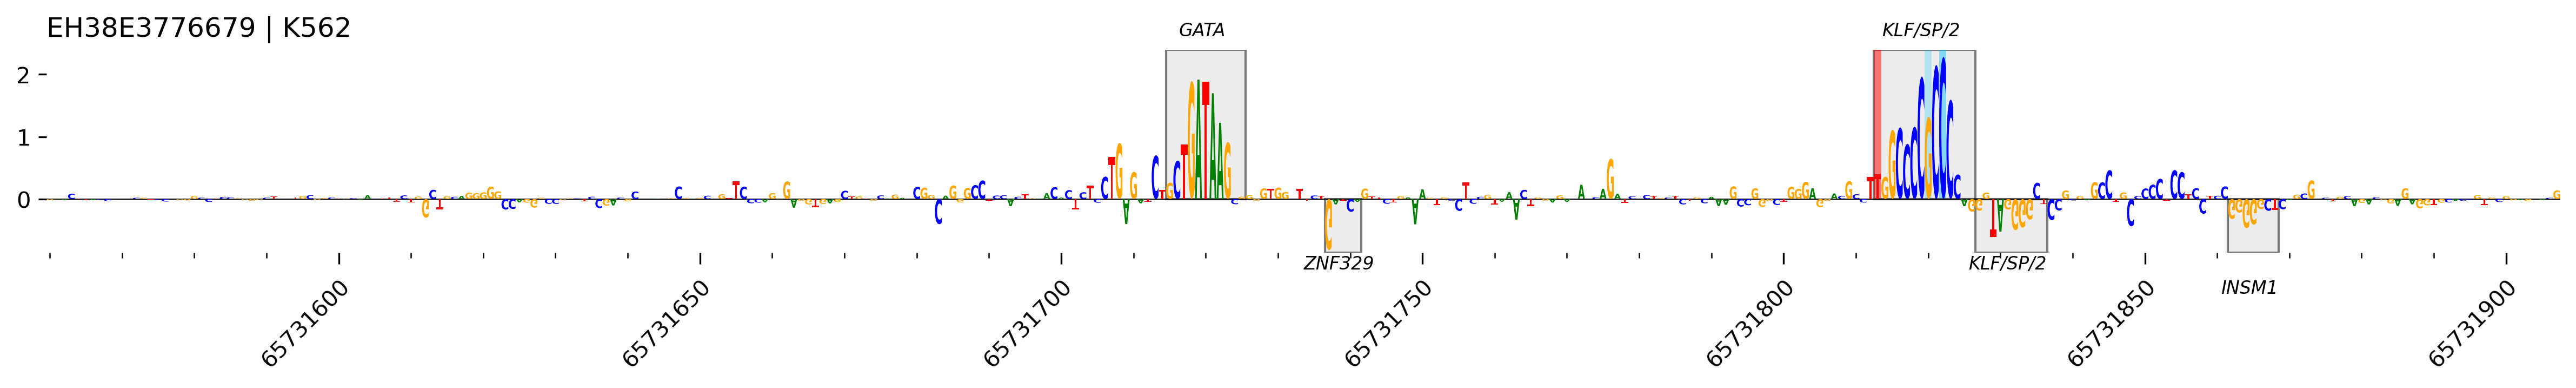

In [36]:
# EH38E3776679
# chr7:65,731,559-65,731,907
# lead Delta: 1.442047, 1.713817
# phenotype id: ENSG00000236529.2
# gene name: ENSG00000236529
# tissue: cells_cultured_fibroblasts
# biotype: lncRNA
plot_specific_enhancers_v2(
    'EH38E3776679',
    65731559,
    'chr7',
    k_mpac_collapsed_dels,
    GTExPaddedSummary,
    {'cell_type' : 'k562',
    'enhancer_id' : 'EH38E3776679',
    'phenotype' : 'ENSG00000236529.2'},
    'GTEx',
    'K562'
)

Saved plot: plot_outputs/EH38E3903446_K562_GTEx_logo.pdf
Saved summary: plot_outputs/EH38E3903446_K562_GTEx_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,gtex_id,...,af_eqtl,afc,afc_se,cs_id,cs_size,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
4364,chr9:114552099:G:A,chr9,114552099,G,A,k562,-1.038335,EH38E3903446,True,chr9_114552099_G_A_b38,...,0.346687,-1.485546,0.103312,1,1,1.038335,1.038335,2.499703,2.407413,False
4384,chr9:114552154:T:G,chr9,114552154,T,G,k562,-2.190342,EH38E3903446,True,chr9_114552154_T_G_b38,...,0.346687,-1.485546,0.103312,1,1,2.190342,1.038335,2.499703,2.407413,True


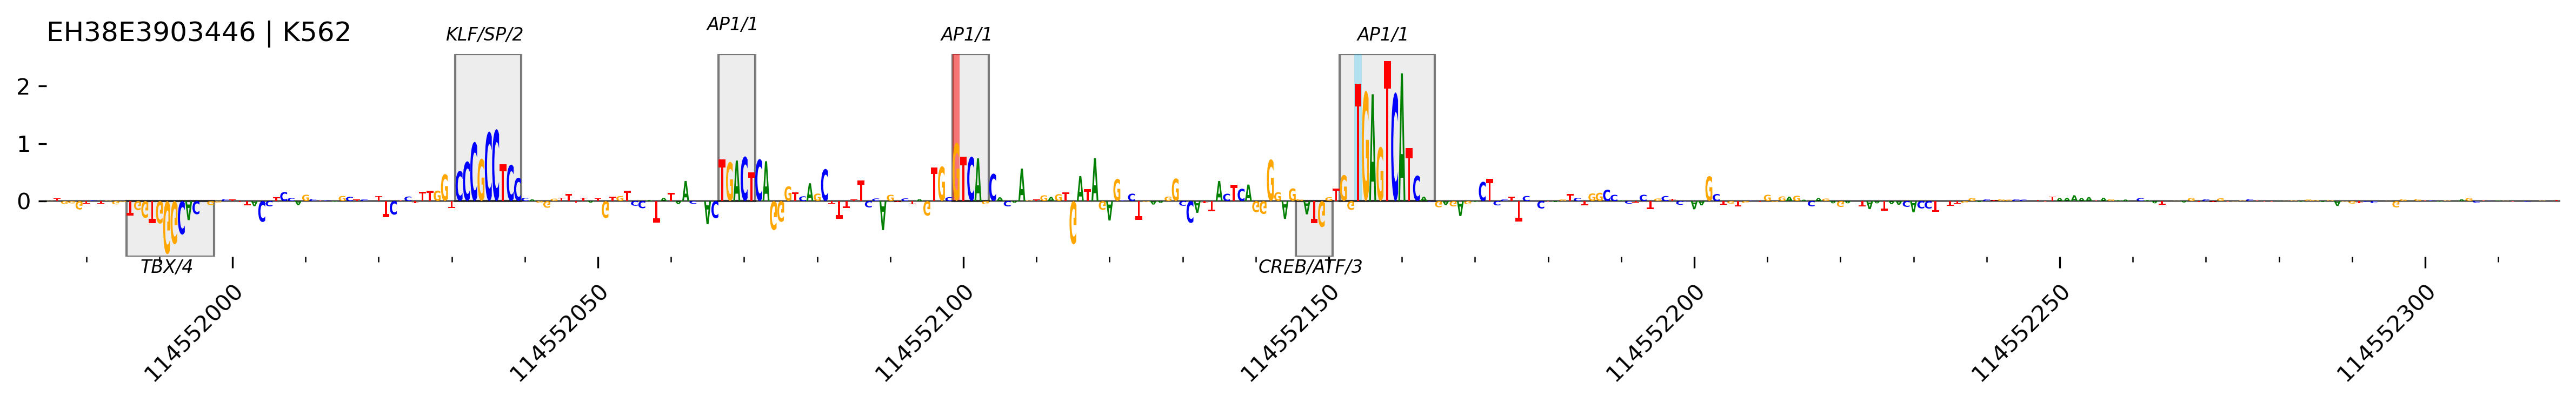

In [37]:
# EH38E3903446
# lead Delta: 1.152007
# phenotype id: ENSG00000095397.16
# gene name: WHRN
# tissue: cells_cultured_fibroblasts
# biotype: protein_coding
plot_specific_enhancers_v2(
    'EH38E3903446',
    114551974,
    'chr9',
    k_mpac_collapsed_dels,
    GTExPaddedSummary,
    {'cell_type' : 'k562',
    'enhancer_id' : 'EH38E3903446',
    'phenotype' : 'ENSG00000095397.16'},
    'GTEx',
    'K562'
)
# at position 114552098 there is a C instead of an A, weakening the AP/1 motif
# MPAC predicts that C-> to strongly increase expression in all cell types
# chr9	114552098	EH38E3903446	C	A	4.1033745	5.7116165	1.6082418	3.0790224	4.0576935	0.97867095	3.165228	4.289769	1.1245414
# similarly G->T at 114552103 strengthens the motif and predicted to increase expression
# chr9	114552103	EH38E3903446	G	T	4.1975427	4.712678	0.51513535	3.1151578	3.6658368	0.5506788	3.2200916	3.957557	0.7374657
# expressed in K562: 0.9 (log10 TPM + 1)

Saved plot: plot_outputs/EH38E3688576_K562_GTEx_logo.pdf
Saved summary: plot_outputs/EH38E3688576_K562_GTEx_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,gtex_id,...,af_eqtl,afc,afc_se,cs_id,cs_size,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
4915,chr6:6682419:A:T,chr6,6682419,A,T,k562,-0.533834,EH38E3688576,True,chr6_6682419_A_T_b38,...,0.5,-0.556648,0.092211,1,1,0.533834,0.800041,1.841645,2.301939,False
4917,chr6:6682429:A:C,chr6,6682429,A,C,k562,-0.800041,EH38E3688576,True,chr6_6682429_A_C_b38,...,0.5,-0.556648,0.092211,1,1,0.800041,0.800041,1.841645,2.301939,False
4921,chr6:6682429:A:T,chr6,6682429,A,T,k562,-0.950806,EH38E3688576,True,chr6_6682429_A_T_b38,...,0.5,-0.556648,0.092211,1,1,0.950806,0.800041,1.841645,2.301939,True
4931,chr6:6682431:T:C,chr6,6682431,T,C,k562,-0.689262,EH38E3688576,True,chr6_6682431_T_C_b38,...,0.5,-0.556648,0.092211,1,1,0.689262,0.800041,1.841645,2.301939,False
4957,chr6:6682435:T:G,chr6,6682435,T,G,k562,1.039374,EH38E3688576,True,chr6_6682435_T_G_b38,...,0.5,-0.556648,0.092211,1,1,1.039374,0.800041,1.841645,2.301939,True
4975,chr6:6682484:G:A,chr6,6682484,G,A,k562,-1.388678,EH38E3688576,True,chr6_6682484_G_A_b38,...,0.5,-0.556648,0.092211,1,1,1.388678,0.800041,1.841645,2.301939,True


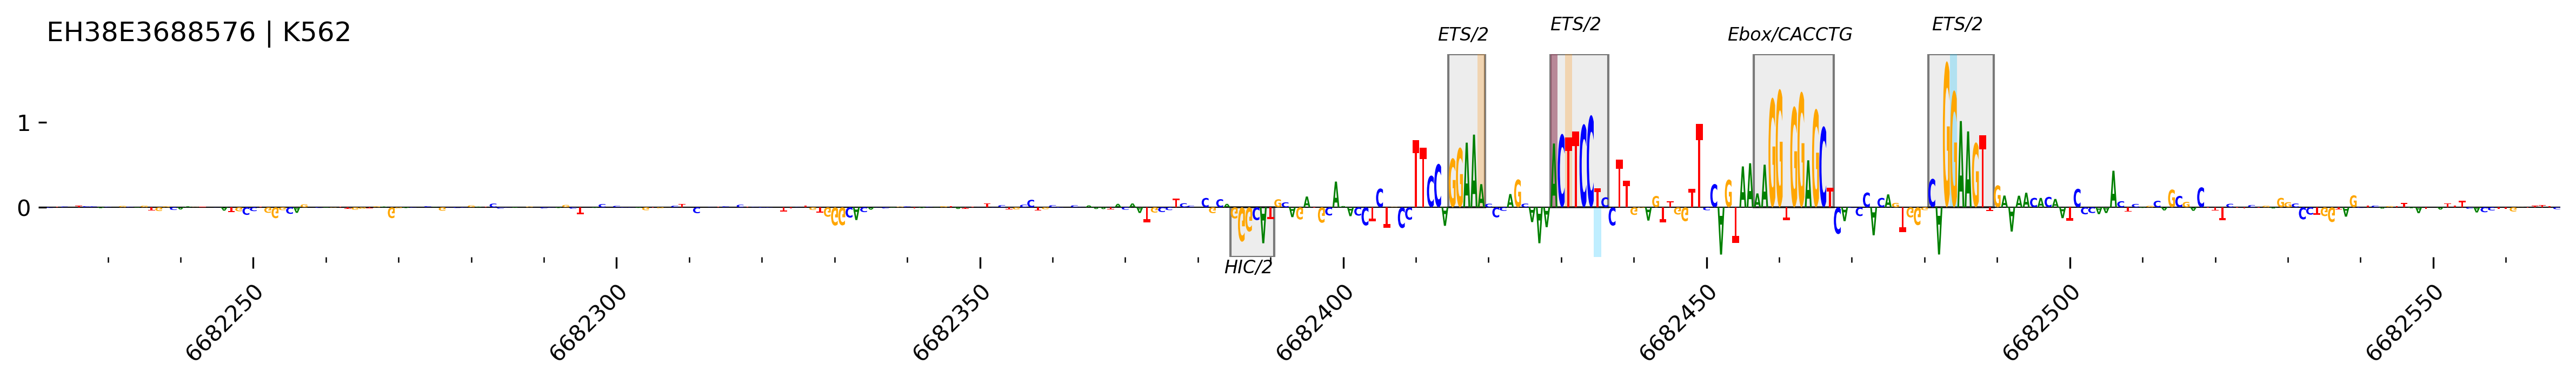

In [38]:
# EH38E3688576
# chr6:6,682,221-6,682,567
# lead Delta: 0.588637
# phenotype id: ENSG00000216863.10
# gene name: LY86-AS1
# tissue: Whole_Blood
# biotype: lncRNA
plot_specific_enhancers_v2(
    'EH38E3688576',
    6682221,
    'chr6',
    k_mpac_collapsed_dels,
    GTExPaddedSummary,
    {'cell_type' : 'k562',
    'enhancer_id' : 'EH38E3688576',
    'phenotype' : 'ENSG00000216863.10'},
    'GTEx',
    'K562'
)

Saved plot: plot_outputs/EH38E3688576_K562_GTEx_logo.pdf
Saved summary: plot_outputs/EH38E3688576_K562_GTEx_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,gtex_id,...,af_eqtl,afc,afc_se,cs_id,cs_size,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
4916,chr6:6682419:A:T,chr6,6682419,A,T,k562,-0.533834,EH38E3688576,True,chr6_6682419_A_T_b38,...,0.5,-1.255423,0.104885,1,1,0.533834,0.800041,1.841645,2.301939,False
4918,chr6:6682429:A:C,chr6,6682429,A,C,k562,-0.800041,EH38E3688576,True,chr6_6682429_A_C_b38,...,0.5,-1.255423,0.104885,1,1,0.800041,0.800041,1.841645,2.301939,False
4922,chr6:6682429:A:T,chr6,6682429,A,T,k562,-0.950806,EH38E3688576,True,chr6_6682429_A_T_b38,...,0.5,-1.255423,0.104885,1,1,0.950806,0.800041,1.841645,2.301939,True
4932,chr6:6682431:T:C,chr6,6682431,T,C,k562,-0.689262,EH38E3688576,True,chr6_6682431_T_C_b38,...,0.5,-1.255423,0.104885,1,1,0.689262,0.800041,1.841645,2.301939,False
4958,chr6:6682435:T:G,chr6,6682435,T,G,k562,1.039374,EH38E3688576,True,chr6_6682435_T_G_b38,...,0.5,-1.255423,0.104885,1,1,1.039374,0.800041,1.841645,2.301939,True
4976,chr6:6682484:G:A,chr6,6682484,G,A,k562,-1.388678,EH38E3688576,True,chr6_6682484_G_A_b38,...,0.5,-1.255423,0.104885,1,1,1.388678,0.800041,1.841645,2.301939,True


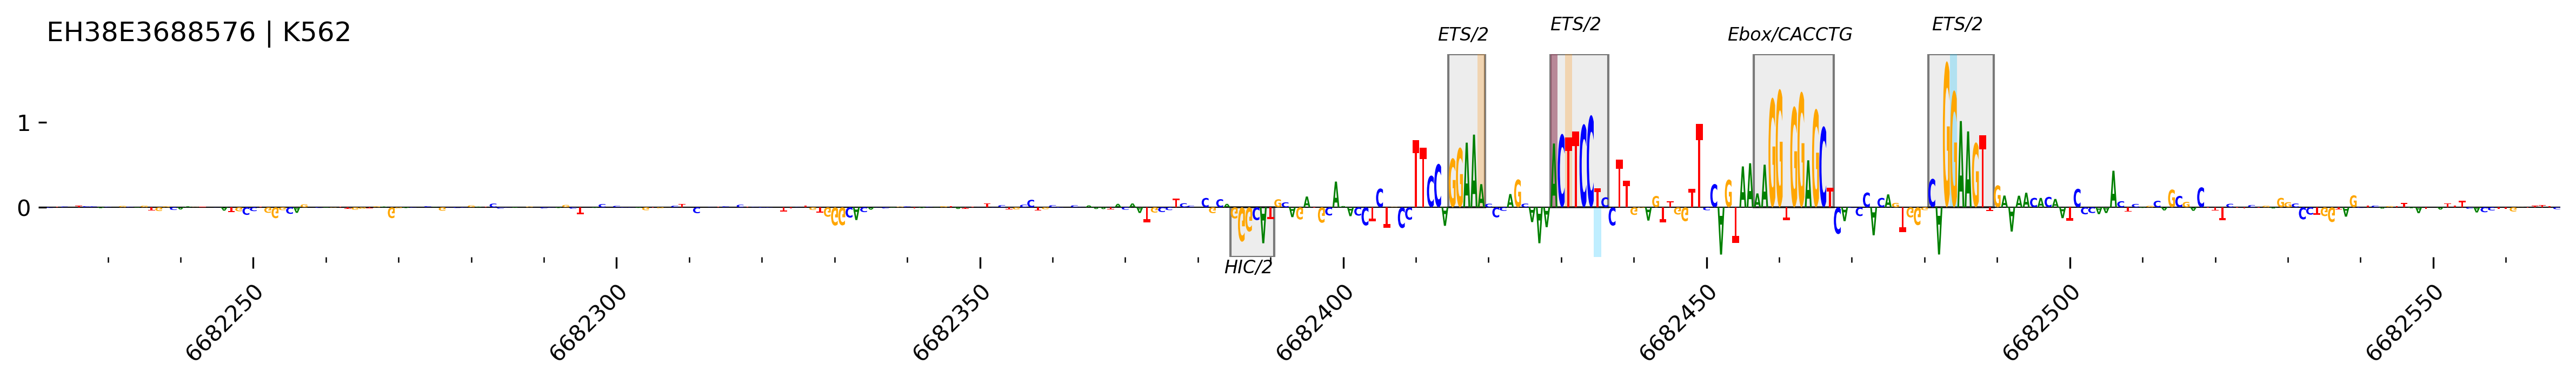

In [39]:
# EH38E3688576
# chr6:6,682,221-6,682,567
# lead Delta: 0.588637
# phenotype id: ENSG00000261211.2
# gene name: ENSG00000261211
# tissue: Whole_Blood
# biotype: lncRNA
plot_specific_enhancers_v2(
    'EH38E3688576',
    6682221,
    'chr6',
    k_mpac_collapsed_dels,
    GTExPaddedSummary,
    {'cell_type' : 'k562',
    'enhancer_id' : 'EH38E3688576',
    'phenotype' : 'ENSG00000261211.2'},
    'GTEx',
    'K562'
)

Saved plot: plot_outputs/EH38E3417196_K562_GTEx_logo.pdf
Saved summary: plot_outputs/EH38E3417196_K562_GTEx_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,gtex_id,...,af_eqtl,afc,afc_se,cs_id,cs_size,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
5966,chr20:3753833:C:T,chr20,3753833,C,T,k562,-1.131608,EH38E3417196,True,chr20_3753833_C_T_b38,...,0.348586,-0.257179,0.070329,2,1,1.131608,0.500018,2.029712,4.059276,True
5967,chr20:3753834:G:A,chr20,3753834,G,A,k562,-1.076284,EH38E3417196,True,chr20_3753834_G_A_b38,...,0.348586,-0.257179,0.070329,2,1,1.076284,0.500018,2.029712,4.059276,True
5970,chr20:3753835:G:A,chr20,3753835,G,A,k562,-0.948986,EH38E3417196,True,chr20_3753835_G_A_b38,...,0.348586,-0.257179,0.070329,2,1,0.948986,0.500018,2.029712,4.059276,True
5976,chr20:3753862:G:A,chr20,3753862,G,A,k562,-0.732628,EH38E3417196,True,chr20_3753862_G_A_b38,...,0.348586,-0.257179,0.070329,2,1,0.732628,0.500018,2.029712,4.059276,True
5988,chr20:3753866:G:A,chr20,3753866,G,A,k562,-0.623674,EH38E3417196,True,chr20_3753866_G_A_b38,...,0.348586,-0.257179,0.070329,2,1,0.623674,0.500018,2.029712,4.059276,True
5992,chr20:3753867:T:C,chr20,3753867,T,C,k562,-0.500018,EH38E3417196,True,chr20_3753867_T_C_b38,...,0.348586,-0.257179,0.070329,2,1,0.500018,0.500018,2.029712,4.059276,False
6014,chr20:3753928:G:A,chr20,3753928,G,A,k562,-0.901252,EH38E3417196,True,chr20_3753928_G_A_b38,...,0.348586,-0.257179,0.070329,2,1,0.901252,0.500018,2.029712,4.059276,True
6016,chr20:3753928:G:T,chr20,3753928,G,T,k562,-0.696316,EH38E3417196,True,chr20_3753928_G_T_b38,...,0.348586,-0.257179,0.070329,2,1,0.696316,0.500018,2.029712,4.059276,True
6021,chr20:3753932:G:C,chr20,3753932,G,C,k562,2.029712,EH38E3417196,True,chr20_3753932_G_C_b38,...,0.348586,-0.257179,0.070329,2,1,2.029712,0.500018,2.029712,4.059276,True


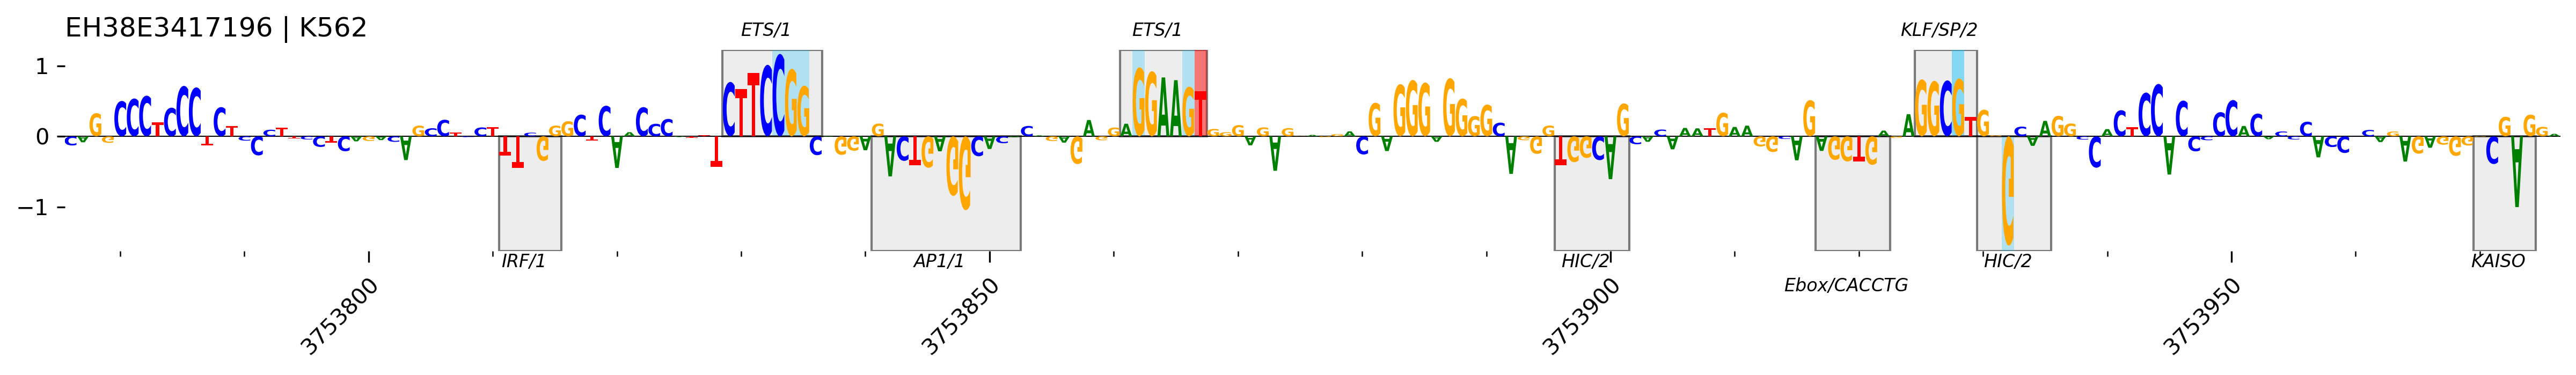

In [40]:
# EH38E3417196
# chr20:3,753,775-3,753,976
# lead Delta: 0.631590, 0.576266
# phenotype id: ENSG00000101220.18
# gene name: C20orf27
# tissue: Lung
# biotype: protein_coding
plot_specific_enhancers_v2(
    'EH38E3417196',
    3753775,
    'chr20',
    k_mpac_collapsed_dels,
    GTExPaddedSummary,
    {'cell_type' : 'k562',
    'enhancer_id' : 'EH38E3417196',
    'phenotype' : 'ENSG00000101220.18'},
    'GTEx',
    'K562'
)

In [ ]:
### HepG2 High Delta ###

Saved plot: plot_outputs/EH38E1908595_HepG2_GTEx_logo.pdf
Saved summary: plot_outputs/EH38E1908595_HepG2_GTEx_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,gtex_id,...,af_eqtl,afc,afc_se,cs_id,cs_size,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
6141,chr18:34153887:G:C,chr18,34153887,G,C,hepg2,-0.510436,EH38E1908595,True,chr18_34153887_G_C_b38,...,0.011765,-1.664438,1.072828,1,2,0.510436,0.510436,1.690453,3.311785,False
6177,chr18:34153910:G:A,chr18,34153910,G,A,hepg2,-1.311947,EH38E1908595,True,chr18_34153910_G_A_b38,...,0.011765,-1.664438,1.072828,1,2,1.311947,0.510436,1.690453,3.311785,True
6186,chr18:34153913:G:A,chr18,34153913,G,A,hepg2,-0.894854,EH38E1908595,True,chr18_34153913_G_A_b38,...,0.011765,-1.664438,1.072828,1,2,0.894854,0.510436,1.690453,3.311785,True


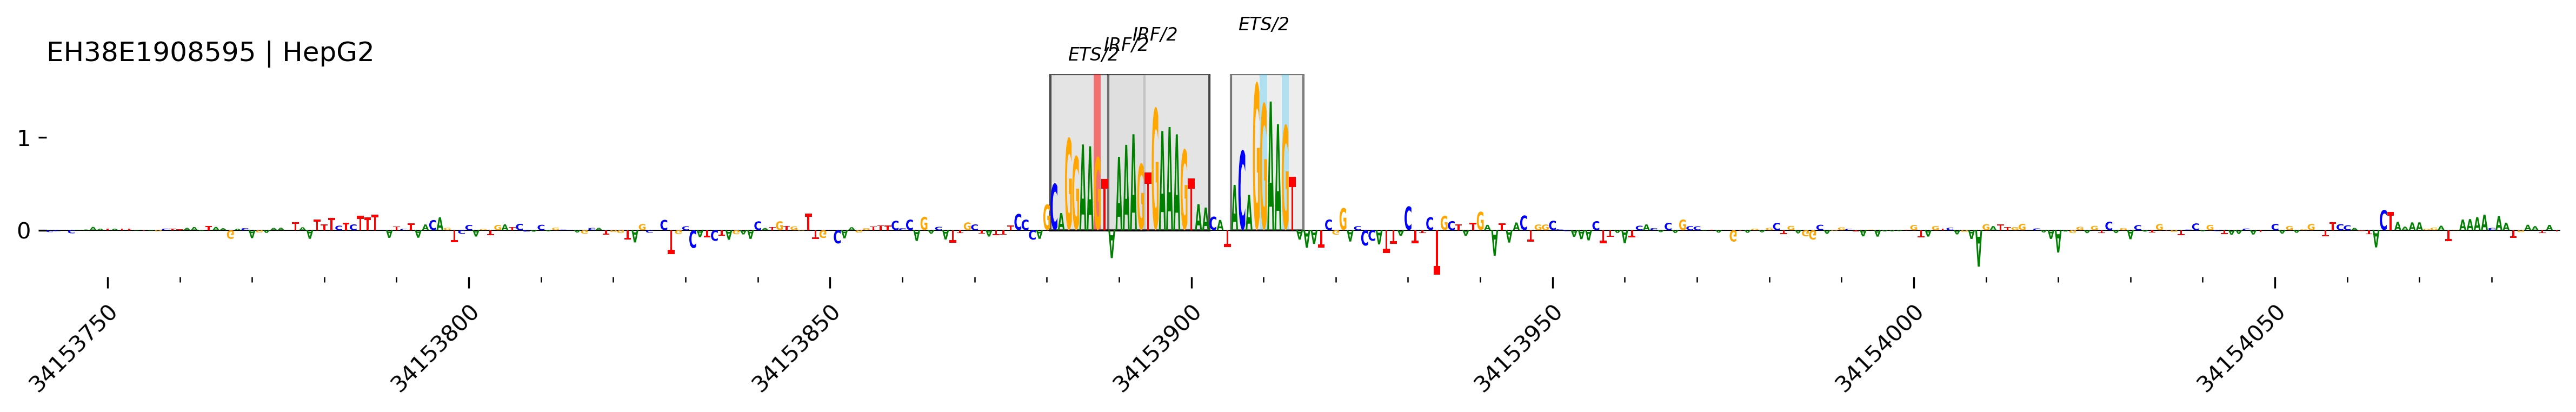

In [41]:
# EH38E1908595
# chr18:34,153,741-34,154,089
# lead Delta: 0.801511
# phenotype id: ENSG00000141431.13
# gene name: ASXL3
# tissue: Vagina
# biotype: protein_coding
plot_specific_enhancers_v2(
    'EH38E1908595',
    34153741,
    'chr18',
    h_mpac_collapsed_dels,
    GTExPaddedSummary,
    {'cell_type' : 'hepg2',
    'enhancer_id' : 'EH38E1908595',
    'phenotype' : 'ENSG00000141431.13'},
    'GTEx',
    'HepG2'
)

Saved plot: plot_outputs/EH38E3688576_HepG2_GTEx_logo.pdf
Saved summary: plot_outputs/EH38E3688576_HepG2_GTEx_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,gtex_id,...,af_eqtl,afc,afc_se,cs_id,cs_size,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
5005,chr6:6682429:A:C,chr6,6682429,A,C,hepg2,-0.524514,EH38E3688576,True,chr6_6682429_A_C_b38,...,0.5,-0.556648,0.092211,1,1,0.524514,0.524514,1.499674,2.85917,False
5007,chr6:6682429:A:T,chr6,6682429,A,T,hepg2,-0.623538,EH38E3688576,True,chr6_6682429_A_T_b38,...,0.5,-0.556648,0.092211,1,1,0.623538,0.524514,1.499674,2.85917,True
5017,chr6:6682431:T:C,chr6,6682431,T,C,hepg2,-0.549141,EH38E3688576,True,chr6_6682431_T_C_b38,...,0.5,-0.556648,0.092211,1,1,0.549141,0.524514,1.499674,2.85917,True
5041,chr6:6682435:T:G,chr6,6682435,T,G,hepg2,1.091953,EH38E3688576,True,chr6_6682435_T_G_b38,...,0.5,-0.556648,0.092211,1,1,1.091953,0.524514,1.499674,2.85917,True
5061,chr6:6682484:G:A,chr6,6682484,G,A,hepg2,-1.287338,EH38E3688576,True,chr6_6682484_G_A_b38,...,0.5,-0.556648,0.092211,1,1,1.287338,0.524514,1.499674,2.85917,True


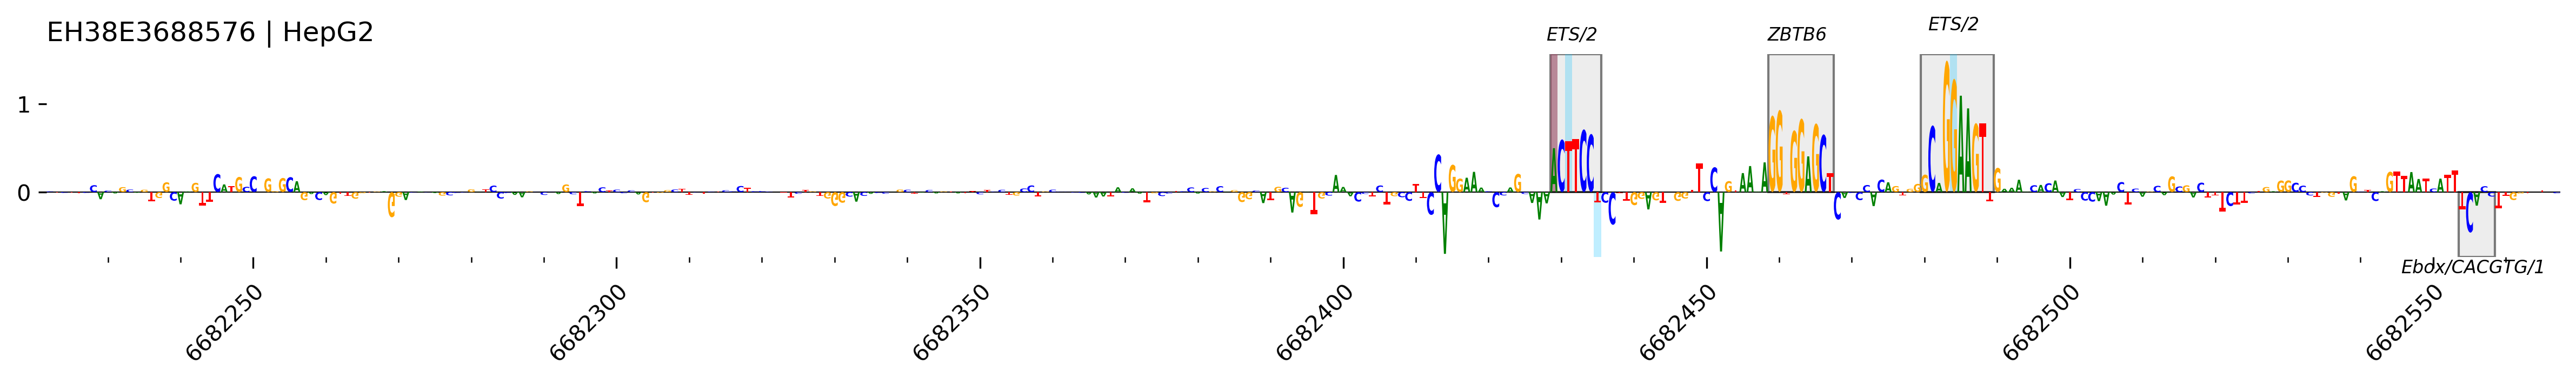

In [42]:
# EH38E3688576
# chr6:6,682,221-6,682,567
# lead Delta: 0.588637
# phenotype id: ENSG00000216863.10
# gene name: LY86-AS1
# tissue: Whole_Blood
# biotype: lncRNA
plot_specific_enhancers_v2(
    'EH38E3688576',
    6682221,
    'chr6',
    h_mpac_collapsed_dels,
    GTExPaddedSummary,
    {'cell_type' : 'hepg2',
    'enhancer_id' : 'EH38E3688576',
    'phenotype' : 'ENSG00000216863.10'},
    'GTEx',
    'HepG2'
)

Saved plot: plot_outputs/EH38E3688576_HepG2_GTEx_logo.pdf
Saved summary: plot_outputs/EH38E3688576_HepG2_GTEx_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,gtex_id,...,af_eqtl,afc,afc_se,cs_id,cs_size,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
5006,chr6:6682429:A:C,chr6,6682429,A,C,hepg2,-0.524514,EH38E3688576,True,chr6_6682429_A_C_b38,...,0.5,-1.255423,0.104885,1,1,0.524514,0.524514,1.499674,2.85917,False
5008,chr6:6682429:A:T,chr6,6682429,A,T,hepg2,-0.623538,EH38E3688576,True,chr6_6682429_A_T_b38,...,0.5,-1.255423,0.104885,1,1,0.623538,0.524514,1.499674,2.85917,True
5018,chr6:6682431:T:C,chr6,6682431,T,C,hepg2,-0.549141,EH38E3688576,True,chr6_6682431_T_C_b38,...,0.5,-1.255423,0.104885,1,1,0.549141,0.524514,1.499674,2.85917,True
5042,chr6:6682435:T:G,chr6,6682435,T,G,hepg2,1.091953,EH38E3688576,True,chr6_6682435_T_G_b38,...,0.5,-1.255423,0.104885,1,1,1.091953,0.524514,1.499674,2.85917,True
5062,chr6:6682484:G:A,chr6,6682484,G,A,hepg2,-1.287338,EH38E3688576,True,chr6_6682484_G_A_b38,...,0.5,-1.255423,0.104885,1,1,1.287338,0.524514,1.499674,2.85917,True


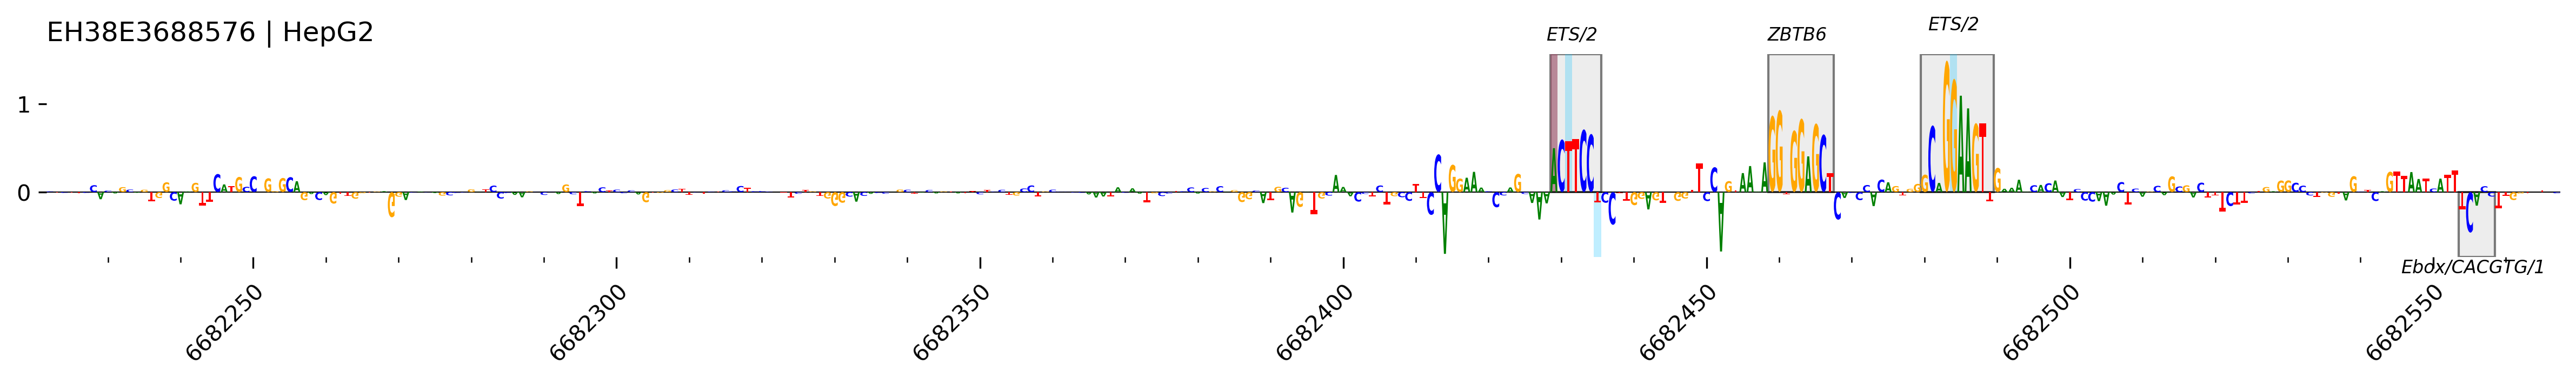

In [43]:
# EH38E3688576
# chr6:6,682,221-6,682,567
# lead Delta: 0.588637
# phenotype id: ENSG00000261211.2
# gene name: ENSG00000261211
# tissue: Whole_Blood
# biotype: lncRNA
plot_specific_enhancers_v2(
    'EH38E3688576',
    6682221,
    'chr6',
    h_mpac_collapsed_dels,
    GTExPaddedSummary,
    {'cell_type' : 'hepg2',
    'enhancer_id' : 'EH38E3688576',
    'phenotype' : 'ENSG00000261211.2'},
    'GTEx',
    'HepG2'
)

In [ ]:
### K562 MEDIUM DELTA (delta > 0.2 and < 0.5) ###

In [ ]:
# EH38E3377181 GWAS variant
# chr2:149,219,895-149,220,241
# mid delta lead variant
# identified in K562
# GATA motif
# 'Bone mineral density mean'
plot_specific_enhancers(
    'EH38E3377181',
    149219895,
    'chr2',
    k_mpac_collapsed_dels,
    149220012,
    [149220009],
    'K562',
    'x'
)

Saved plot: plot_outputs/EH38E2308540_HepG2_GTEx_logo.pdf
Saved summary: plot_outputs/EH38E2308540_HepG2_GTEx_variant_summary.tsv


,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,gtex_id,...,af_eqtl,afc,afc_se,cs_id,cs_size,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,exceeds_lead_skew
4723,chr4:83316634:G:T,chr4,83316634,G,T,hepg2,-0.693954,EH38E2308540,True,chr4_83316634_G_T_b38,...,0.040625,-0.722103,0.301333,1,1,0.693954,0.64101,1.78157,2.779317,True
4757,chr4:83316705:G:A,chr4,83316705,G,A,hepg2,-1.078116,EH38E2308540,True,chr4_83316705_G_A_b38,...,0.040625,-0.722103,0.301333,1,1,1.078116,0.64101,1.78157,2.779317,True
4765,chr4:83316706:G:C,chr4,83316706,G,C,hepg2,-1.106660,EH38E2308540,True,chr4_83316706_G_C_b38,...,0.040625,-0.722103,0.301333,1,1,1.106660,0.64101,1.78157,2.779317,True
4793,chr4:83316727:T:C,chr4,83316727,T,C,hepg2,-0.569622,EH38E2308540,True,chr4_83316727_T_C_b38,...,0.040625,-0.722103,0.301333,1,1,0.569622,0.64101,1.78157,2.779317,False
4823,chr4:83316730:C:G,chr4,83316730,C,G,hepg2,-0.778018,EH38E2308540,True,chr4_83316730_C_G_b38,...,0.040625,-0.722103,0.301333,1,1,0.778018,0.64101,1.78157,2.779317,True
4825,chr4:83316730:C:G,chr4,83316730,C,G,hepg2,-0.778018,EH38E2308540,True,chr4_83316730_C_G_b38,...,0.040625,-0.722103,0.301333,1,1,0.778018,0.64101,1.78157,2.779317,True
4829,chr4:83316730:C:T,chr4,83316730,C,T,hepg2,-0.641010,EH38E2308540,True,chr4_83316730_C_T_b38,...,0.040625,-0.722103,0.301333,1,1,0.641010,0.64101,1.78157,2.779317,False
4831,chr4:83316730:C:T,chr4,83316730,C,T,hepg2,-0.641010,EH38E2308540,True,chr4_83316730_C_T_b38,...,0.040625,-0.722103,0.301333,1,1,0.641010,0.64101,1.78157,2.779317,False


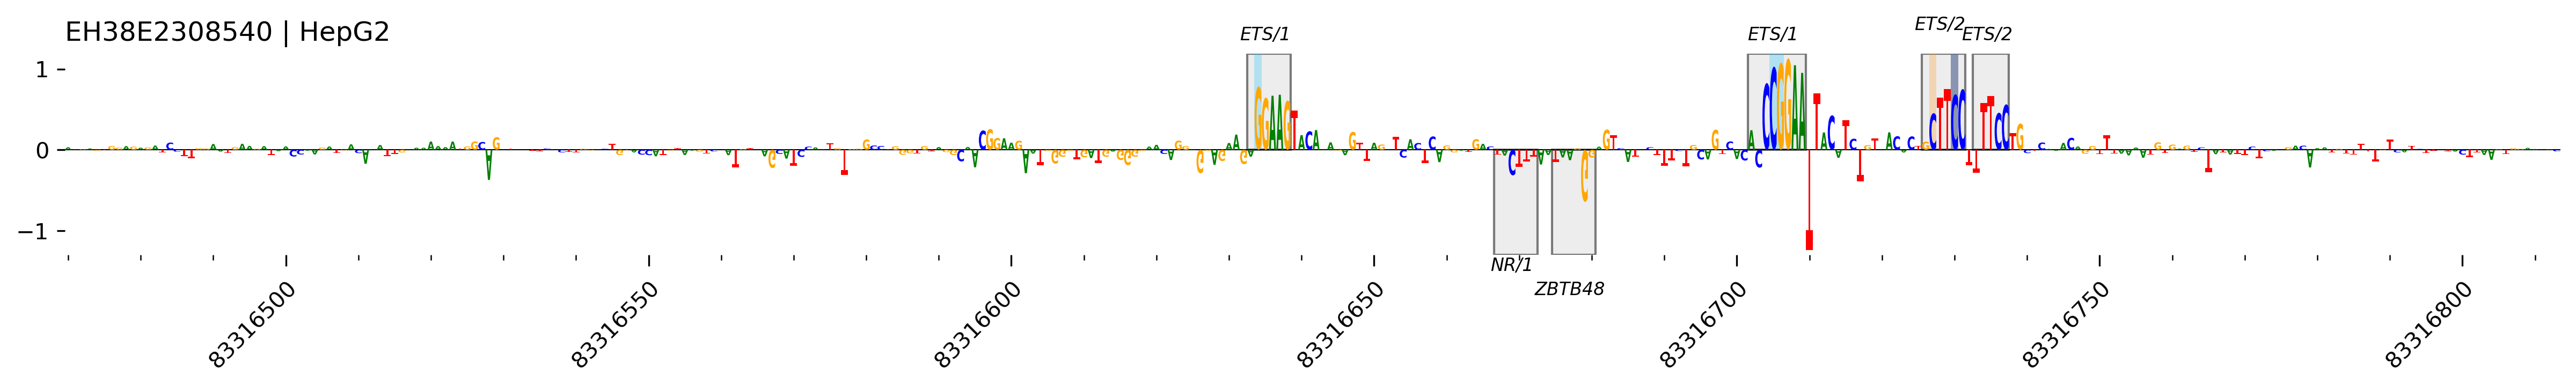

In [15]:
# EH38E2308540
plot_specific_enhancers_v2(
    'EH38E2308540',
    83316469,
    'chr4',
    h_mpac_collapsed_dels,
    GTExPaddedSummary,
    {'cell_type' : 'hepg2',
    'enhancer_id' : 'EH38E2308540',
    'phenotype' : 'ENSG00000173083.16'},
    'GTEx',
    'HepG2'
)